/var/folders/q8/62bq5d2s56b67cdzjyvxn4vc0000gn/T/ipykernel_37144/3716479614.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


------------
cluster= 0
amplitude= 0.846681882346576 idx= (8, 11, 229, 75)
selected elements: 2289542
------------
cluster= 1
amplitude= 0.6644692309640714 idx= (5, 9, 301, 237)
selected elements: 56350
------------
cluster= 2
amplitude= 0.6366080270096394 idx= (5, 5, 345, 15)
selected elements: 312580
------------
cluster= 3
amplitude= 0.5944784569937481 idx= (9, 8, 300, 81)
selected elements: 182456
------------
cluster= 4
amplitude= 0.5494060758655586 idx= (3, 13, 181, 162)
selected elements: 267954
------------
cluster= 5
amplitude= 0.500167860910616 idx= (7, 10, 291, 248)
selected elements: 17097


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 52.09it/s]


Wave 0: peak amp = 0.847+0.000j, lamx=-117.0, lamy=42.6, lam=40.0
Wave 1: peak amp = 0.664+0.000j, lamx=388424520712647360.0, lamy=23.8, lam=23.8


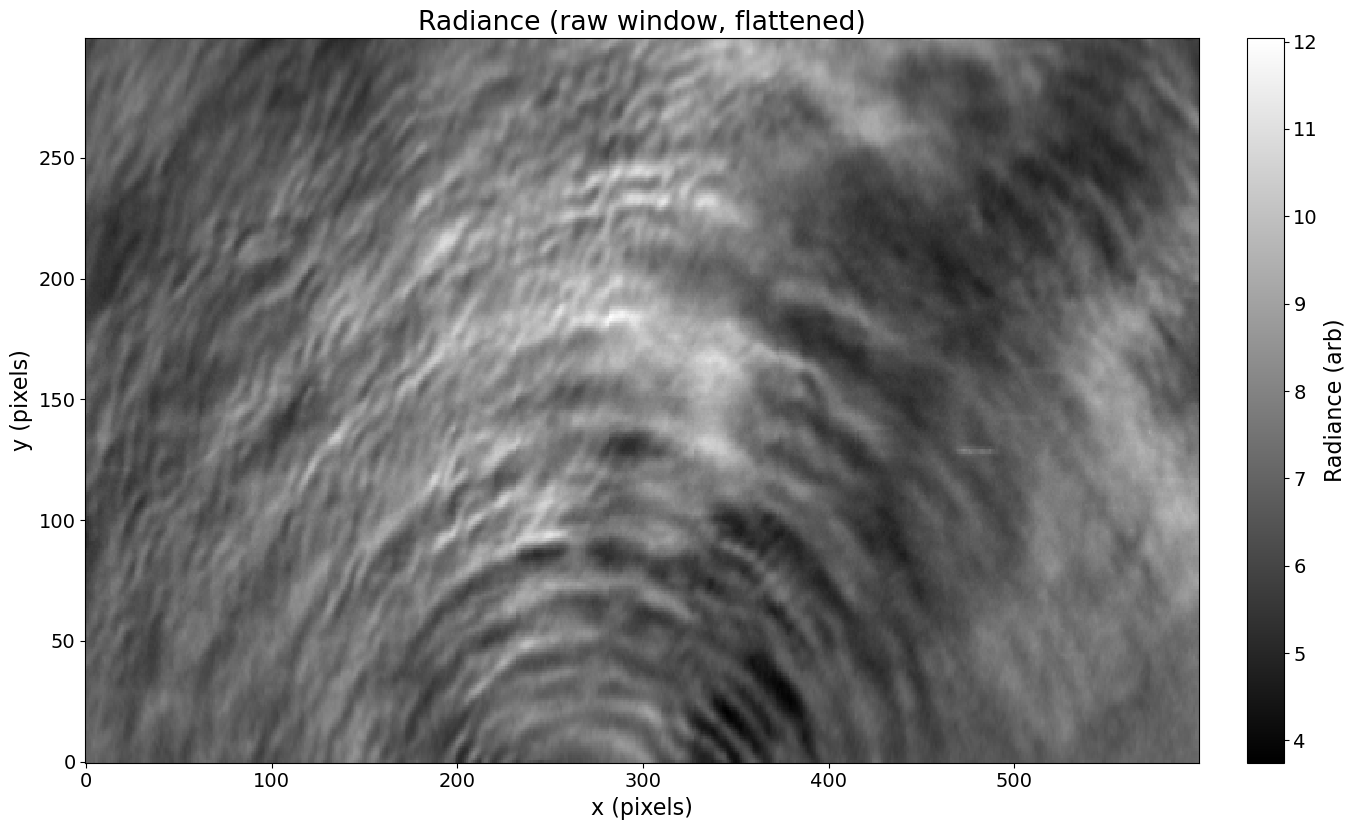

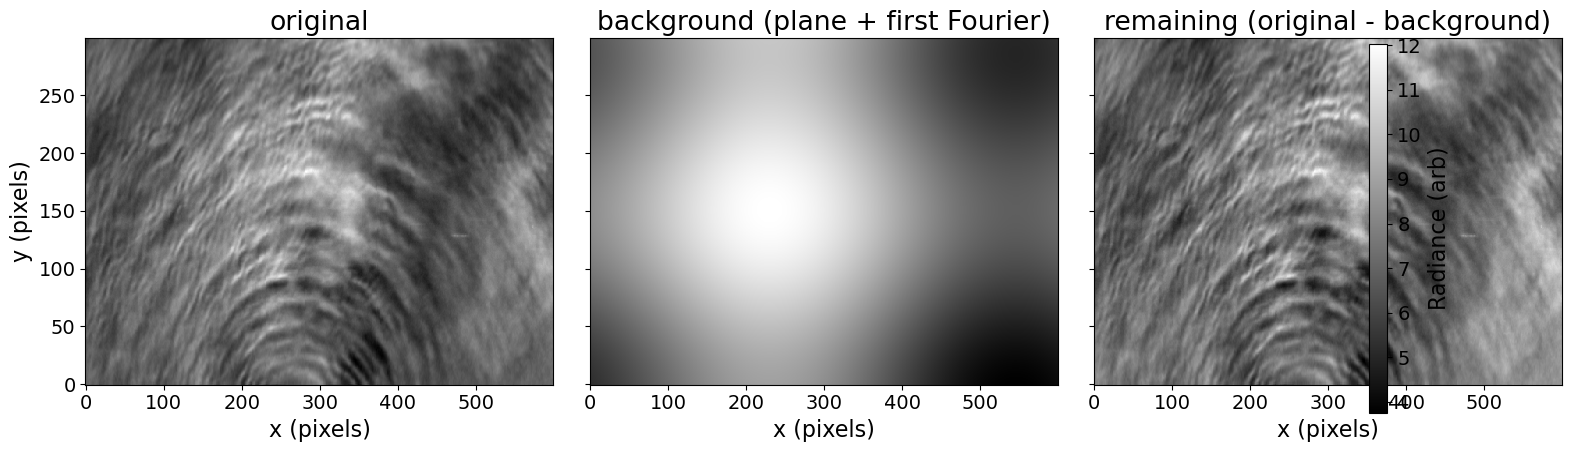

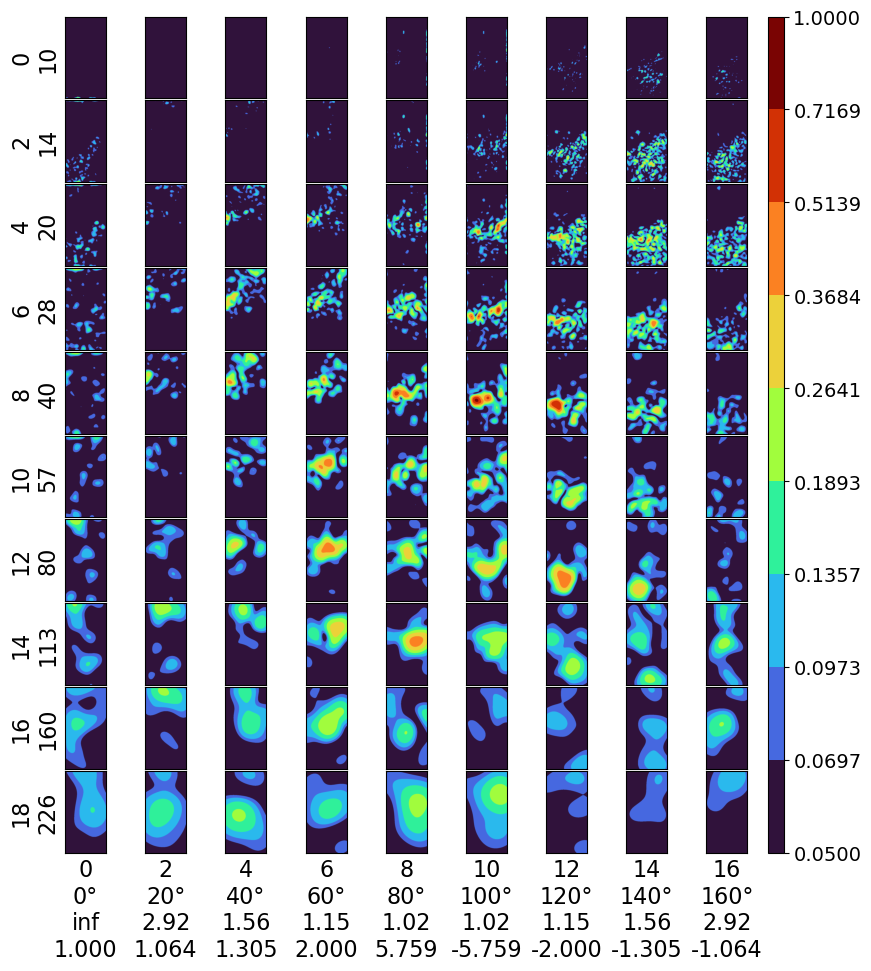

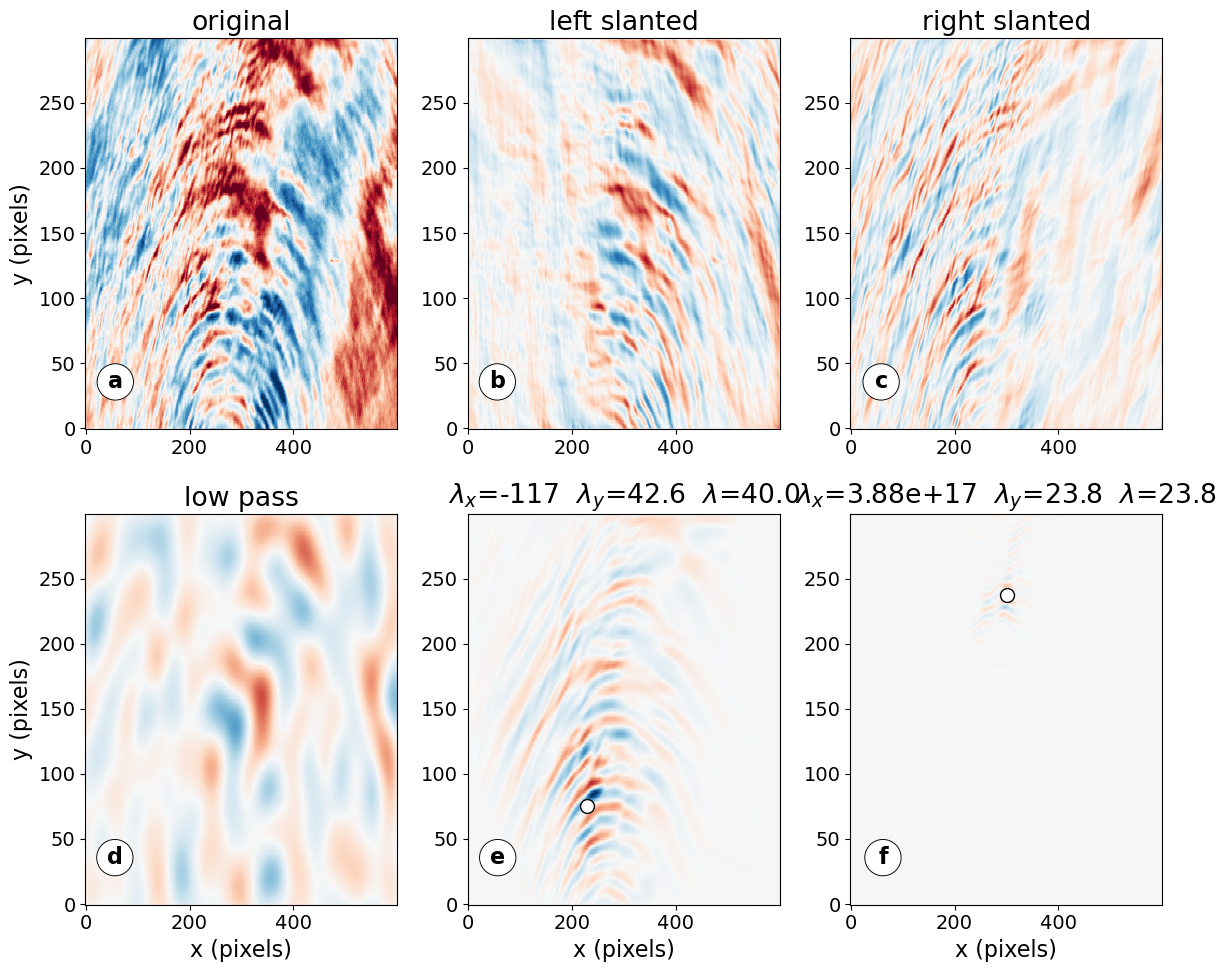

In [12]:
# example_decompose2d_from_nc.py
# Load a radiance window from an AWE NetCDF file, run juwavelet 2D CWT,
# and plot components. No files written.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Tuple
from netCDF4 import Dataset

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
FILE_PATH = "awe_l3c_q20_2024074T0757_01756_v01.nc"  # same folder as notebook/script
FRAME_IDX = 0

# Use pixels for now (unknown km/pixel). Adjust slices to taste.
X_SLICE = slice(3200, 3800)   # columns
Y_SLICE = slice(None, None)   # rows (all) after flatten/crop

# Optional preprocessing
REMOVE_TREND = True      # subtract 2D plane (least squares) before CWT
STANDARDIZE = True       # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0   # 0 disables, else pixels (e.g., 0.8)

# Wavelet params (tune if desired)
S0 = 10
DJ = 0.25
JS = 20
JT = 18
ASPECT = 1

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def read_radiance_frame(path: str, frame_idx: int) -> np.ndarray:
    """
    Read one 2D radiance frame (ny, nx) from the NetCDF file.
    """
    with Dataset(path, "r") as nc:
        rad = nc.variables["Radiance"][:]  # shape (nframe, ny, nx)
    if rad.ndim != 3:
        raise ValueError(f"Radiance expected 3D (t,y,x); got {rad.shape}")
    return np.asarray(rad[frame_idx, :, :], dtype=float)  # (ny, nx)


def flatten_swath(Z: np.ndarray, target_ny: int = 300) -> np.ndarray:
    """
    Shift each column so that its lowest valid pixel (bottom) aligns
    along a straight line, then crop in y so the result has exactly
    target_ny rows if possible.

    After this, we will treat y indices as 0..target_ny-1.
    """
    ny, nx = Z.shape
    out = np.full_like(Z, np.nan)

    # Find the bottom (last finite index) of each column
    bottoms = []
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            bottoms.append(np.nan)
        else:
            bottoms.append(valid_idx.max())

    bottoms = np.array(bottoms)
    valid_bottoms = bottoms[np.isfinite(bottoms)]
    if valid_bottoms.size == 0:
        # Nothing finite, just median fill and crop
        med = np.nanmedian(Z)
        out = np.nan_to_num(Z, nan=med, posinf=med, neginf=med)
        if ny > target_ny:
            out = out[-target_ny:, :]
        return out

    # Common bottom index across all columns (straight bottom)
    max_bottom = int(valid_bottoms.max())

    # Align each column so its bottom lands at max_bottom
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            continue
        bottom = valid_idx.max()
        shift = max_bottom - bottom  # positive => move column downward
        if shift == 0:
            out[:, j] = col
        elif shift > 0:
            # shift downward: bottom -> max_bottom
            out[shift:, j] = col[:ny - shift]
        else:
            # If bottom is already below max_bottom (rare), shift up
            shift_up = -shift
            out[:ny - shift_up, j] = col[shift_up:]

    # Fill NaNs with median
    med = np.nanmedian(out)
    out = np.nan_to_num(out, nan=med, posinf=med, neginf=med)

    # Crop in y so final image has y indices 0..target_ny-1
    # We keep the bottom anchored and trim from the top if needed.
    if target_ny is not None and ny > target_ny:
        start = max_bottom + 1 - target_ny
        if start < 0:
            start = 0
        end = start + target_ny
        out = out[start:end, :]

    return out


def load_radiance_window_from_array(
    Z: np.ndarray,
    xsl: slice,
    ysl: slice,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Take a 2D array Z (already flattened and cropped), apply the
    slices in y and x, and return (x_coords, y_coords, window).

    Z shape: (ny, nx). After flatten_swath with target_ny=300,
    ny should be 300 and y will run from 0 to 299.
    """
    win = np.asarray(Z[ysl, xsl], dtype=float)
    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)
    return x, y, win


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward compatible helper: remove 2D plane from Z.
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        # If SciPy is not available, fall back to no blur
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="gray")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Radiance (arb)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field
      (b) background = 2D plane + first Fourier component in x and y
      (c) remaining = original - background
    """
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    ims = []
    ims.append(axs[0].pcolormesh(x1d, y1d, original, shading="auto", cmap="gray"))
    axs[0].set_title("original")

    ims.append(axs[1].pcolormesh(x1d, y1d, background, shading="auto", cmap="gray"))
    axs[1].set_title("background (plane + first Fourier)")

    ims.append(axs[2].pcolormesh(x1d, y1d, remaining, shading="auto", cmap="gray"))
    axs[2].set_title("remaining (original - background)")

    for ax in axs:
        ax.set_xlabel("x (pixels)")
    axs[0].set_ylabel("y (pixels)")

    # Single colorbar for all panels
    cbar = fig.colorbar(ims[0], ax=axs, fraction=0.046, pad=0.04)
    cbar.set_label("Radiance (arb)")

    fig.tight_layout()


# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Read full 2D radiance frame
    rad2d = read_radiance_frame(FILE_PATH, FRAME_IDX)

    # 2) Flatten swath and crop so y runs from 0 to 299 (300 rows)
    rad2d_flat = flatten_swath(rad2d, target_ny=300)

    # 3) Apply window to the flattened/cropped field
    x1d, y1d, wave = load_radiance_window_from_array(
        rad2d_flat, X_SLICE, Y_SLICE
    )

    # Quicklook of the flattened cropped window
    quicklook(x1d, y1d, wave, "Radiance (raw window, flattened)")

    # ----------------------
    # Background separation:
    # plane + first Fourier component in x and y
    # ----------------------
    proc = wave.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc)
        detrended = proc - plane
    else:
        plane = np.zeros_like(proc)
        detrended = proc

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc - background

    # Three panel plot: original, background, remaining
    quicklook_background_decomp(x1d, y1d, proc, background, remaining)

    # Continue preprocessing on the remaining field
    proc = remaining.copy()

    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        if s > 0:
            proc = (proc - m) / s
        else:
            proc = proc - m

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # Pixel spacing: 2 km/pixel
    dx = 2.0
    dy = 2.0

    # juwavelet expects (nx, ny); our arrays are (ny, nx) so transpose
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=dx, dy=dy, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.1)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # Component panels (same layout as before)
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2)
    opts = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    # original (now the preprocessed field used for CWT)
    axs[0, 0].set_title("original")
    axs[0, 0].pcolormesh(x1d, y1d, proc, **opts)

    # left slanted (theta > pi/2 masked out)
    decomposition[:] = orig
    decomposition[:, (np.pi / 2 < theta)] = 0
    rec = transform.reconstruct2d(cwt)  # (nx, ny)
    axs[1, 0].set_title("left slanted")
    axs[1, 0].pcolormesh(x1d, y1d, rec.T, **opts)

    # right slanted (theta <= np.pi / 2 masked out)
    decomposition[:] = orig
    decomposition[:, (theta <= np.pi / 2)] = 0
    rec = transform.reconstruct2d(cwt)
    axs[2, 0].set_title("right slanted")
    axs[2, 0].pcolormesh(x1d, y1d, rec.T, **opts)

    # low pass (period >= 100 kept)
    decomposition[:] = orig
    decomposition[period < 100] = 0
    rec = transform.reconstruct2d(cwt)
    axs[0, 1].set_title("low pass")
    axs[0, 1].pcolormesh(x1d, y1d, rec.T, **opts)

    # highlight two identified waves (if present)
    demo_indices = [0, 1]
    targets = [(1, axs[1, 1]), (2, axs[2, 1])]

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"   # scientific
        elif abs(v) >= 100:
            return f"{v:.0f}"   # no decimals
        else:
            return f"{v:.1f}"   # one decimal

    for (demo_idx, (rowi, ax)) in zip(demo_indices, targets):
        if isinstance(idxs, (list, tuple)) and demo_idx < len(idxs):
            decomposition[:] = orig
            decomposition[iwave != demo_idx] = 0
            udx = idxs[demo_idx]  # (scale_index, angle_index)

            rec = transform.reconstruct2d(cwt)

            # component wavelengths
            lamx = cwt["wavelength_x"][udx[0], udx[1]]
            lamy = cwt["wavelength_y"][udx[0], udx[1]]

            # overall wavelength along k: λ = 1 / sqrt(λx^{-2} + λy^{-2})
            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec.T, **opts)

            # mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[udx[0], udx[1]].argmax(), decomposition[0, 0].shape
            )
            ax.plot(x1d[max_idx[0]], y1d[max_idx[1]], "o", color="w", mec="k", ms=10)
            print(
                f"Wave {demo_idx}: peak amp = {decomposition[udx[0], udx[1]].max():.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )
        else:
            ax.set_title(f"wave {demo_idx} not found")
            ax.axis("off")

    # labels
    for ax in axs[:, 1]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (pixels)")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


## Fix aspect ratio, colorbar

Take the wavelet amplitude at each scale–angle–pixel: abs(cwt["decomposition"])

Average (or max) over x,y to get a single value per (scale, angle) bin
→ this gives a 2-D array spec[scale, angle]

Plot spec on a polar pcolormesh with:

radius = wavelength (km)

angle = orientation (deg)

color = mean amplitude

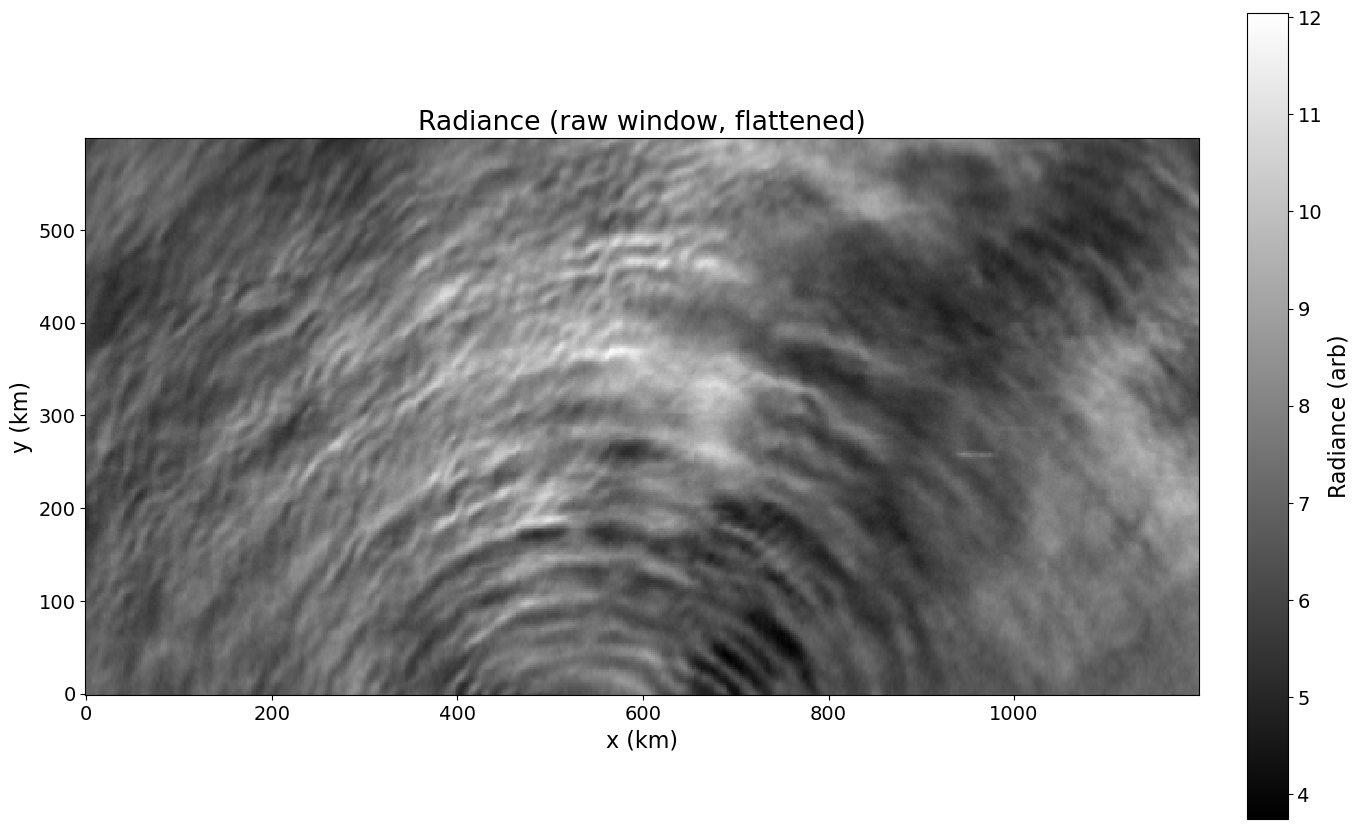

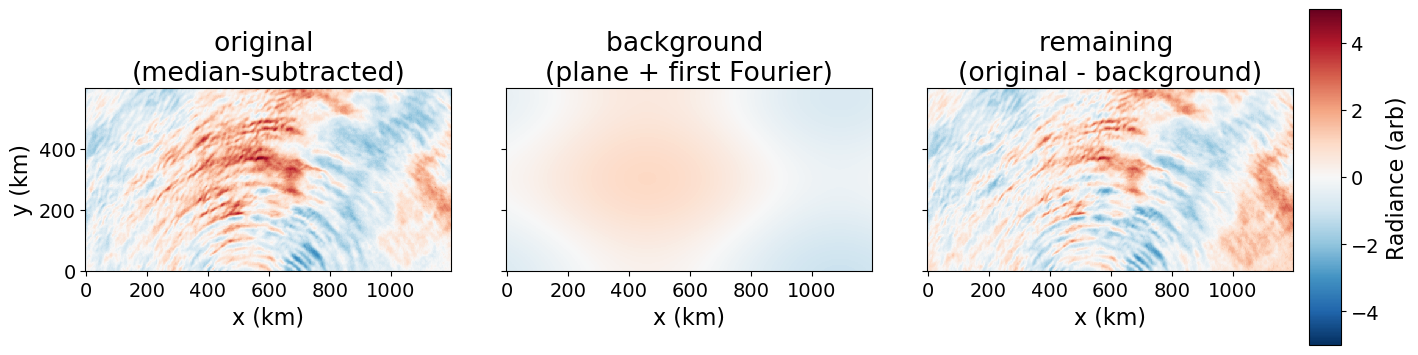

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.8471560879536293 idx= (19, 11, 230, 73)
selected elements: 395542
------------
cluster= 1
amplitude= 0.667399278320878 idx= (13, 9, 301, 237)
selected elements: 110474
------------
cluster= 2
amplitude= 0.6556437647060072 idx= (17, 9, 256, 88)
selected elements: 119635
------------
cluster= 3
amplitude= 0.6506461859771079 idx= (12, 5, 346, 15)
selected elements: 38393
------------
cluster= 4
amplitude= 0.6322707937090495 idx= (16, 12, 202, 88)
selected elements: 42736
------------
cluster= 5
amplitude= 0.5800790734865765 idx= (12, 10, 248, 92)
selected elements: 29530
------------
cluster= 6
amplitude= 0.569143633435533 idx= (10, 13, 181, 162)
selected elements: 52487
------------
cluster= 7
amplitude= 0.5293497269534735 idx= (15, 10, 243, 41)
selected elements: 16946
------------
cluster= 8
amplitude= 0.5105459267720628 idx= (15, 13, 193, 205)
selected elements: 62035
------------
cluster= 9
amplitude= 0.5069987238945658 idx= (21, 10, 266, 143)
sel

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 21.70it/s]
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


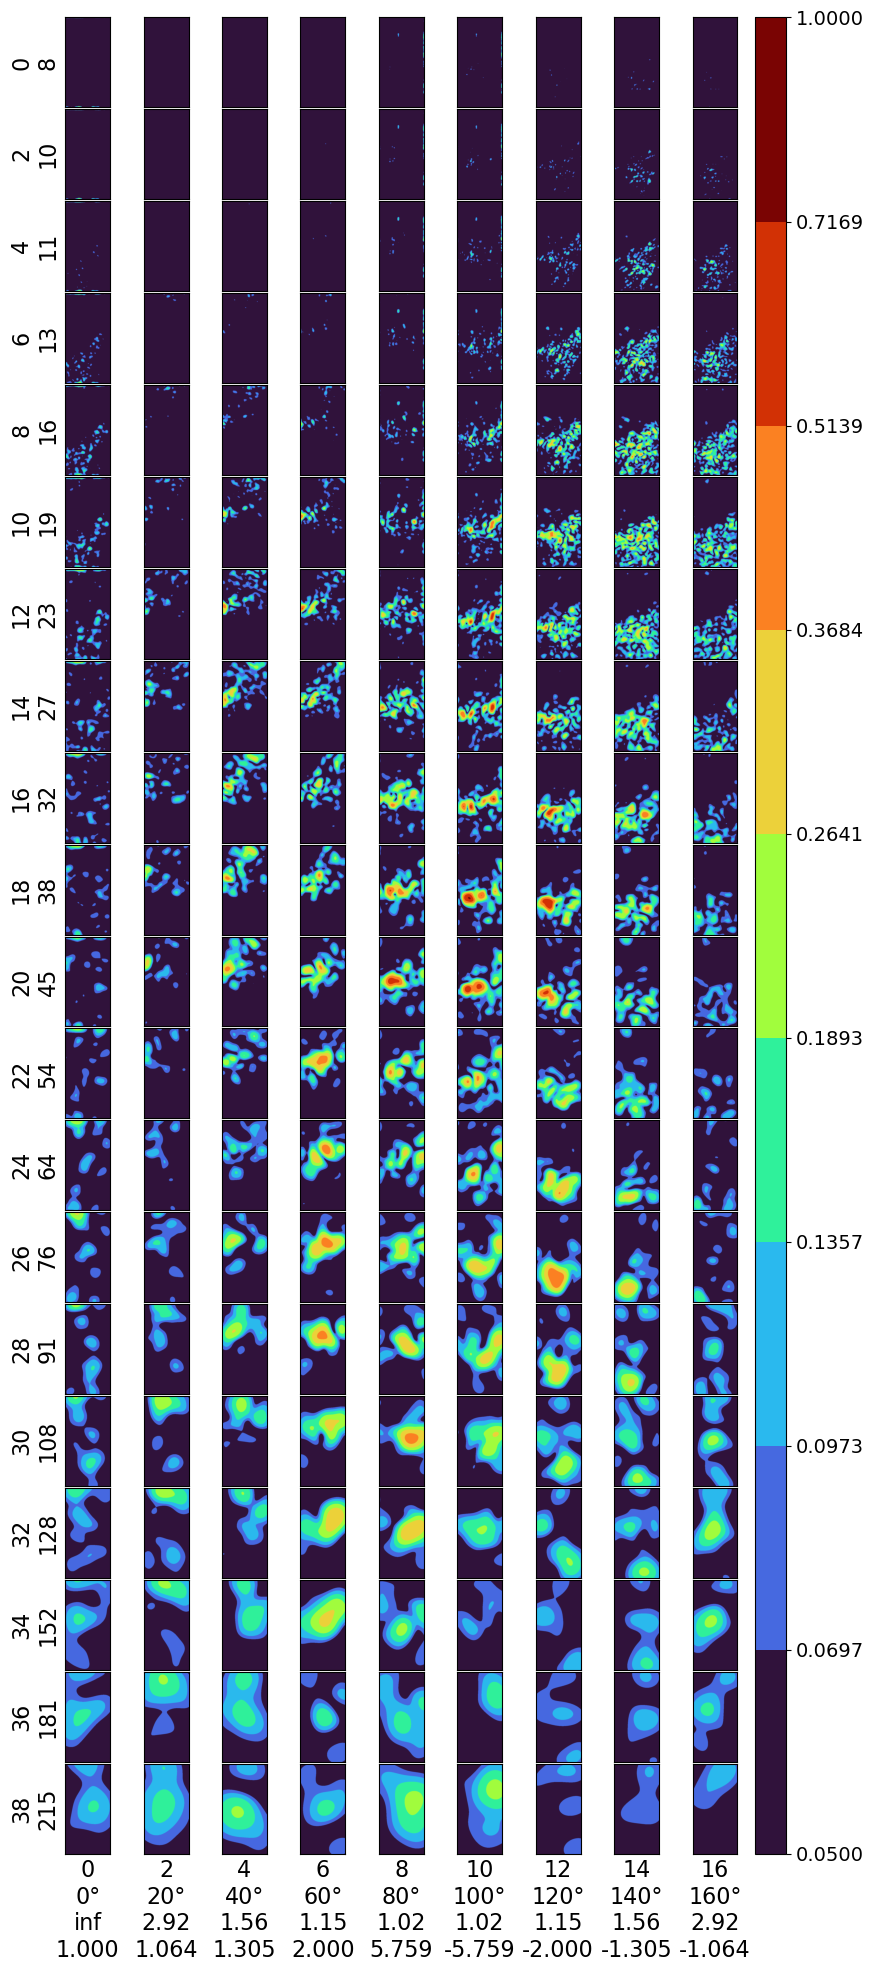

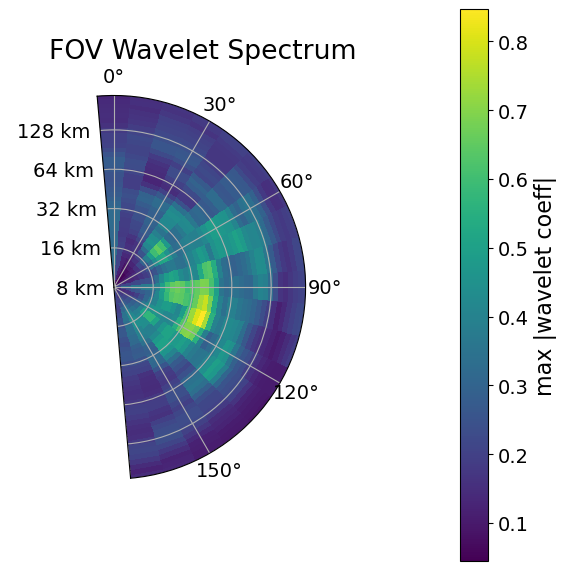

Cluster 0: amp=0.847, lamx=-121.3, lamy=44.2, lam=41.5
Cluster 1: amp=0.667, lamx=402979425965217216.0, lamy=24.7, lam=24.7
Cluster 2: amp=0.656, lamx=569898969557334784.0, lamy=34.9, lam=34.9
Cluster 3: amp=0.651, lamx=35.2, lamy=29.5, lam=22.6
Cluster 4: amp=0.632, lamx=-64.0, lamy=37.0, lam=32.0
Cluster 5: amp=0.580, lamx=-130.3, lamy=23.0, lam=22.6


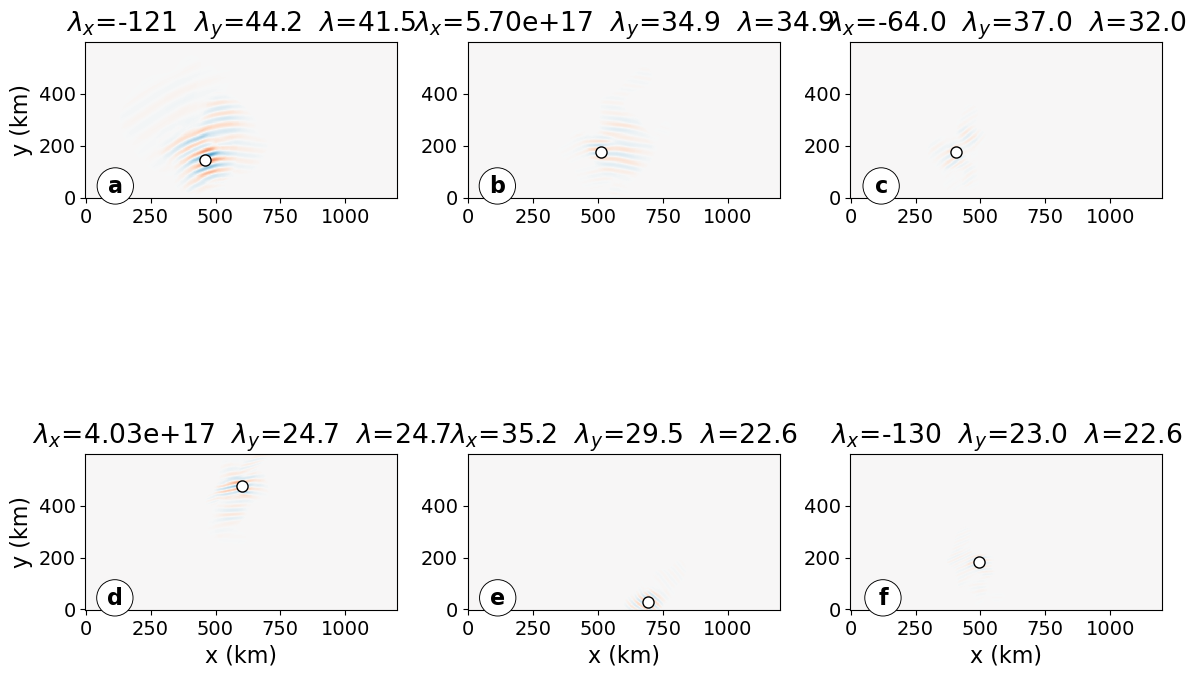

In [37]:
# example_decompose2d_from_nc.py
# Load a radiance window from an AWE NetCDF file, run juwavelet 2D CWT,
# and plot components. No files written.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Tuple
from netCDF4 import Dataset

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
FILE_PATH = "awe_l3c_q20_2024074T0757_01756_v01.nc"  # same folder as notebook/script
FRAME_IDX = 0

# Use pixels for now (unknown km/pixel). Adjust slices to taste.
X_SLICE = slice(3200, 3800)   # columns
Y_SLICE = slice(None, None)   # rows (all) after flatten/crop

# Optional preprocessing
REMOVE_TREND = True      # subtract 2D plane (least squares) before CWT
STANDARDIZE = True       # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0   # 0 disables, else pixels (e.g., 0.8)

# Wavelet params (tune if desired)
S0 = 8
DJ = 1/8
JS = 40
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel)
DX_KM = 2.0
DY_KM = 2.0

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def read_radiance_frame(path: str, frame_idx: int) -> np.ndarray:
    """
    Read one 2D radiance frame (ny, nx) from the NetCDF file.
    """
    with Dataset(path, "r") as nc:
        rad = nc.variables["Radiance"][:]  # shape (nframe, ny, nx)
    if rad.ndim != 3:
        raise ValueError(f"Radiance expected 3D (t,y,x); got {rad.shape}")
    return np.asarray(rad[frame_idx, :, :], dtype=float)  # (ny, nx)


def flatten_swath(Z: np.ndarray, target_ny: int = 300) -> np.ndarray:
    """
    Shift each column so that its lowest valid pixel (bottom) aligns
    along a straight line, then crop in y so the result has exactly
    target_ny rows if possible.

    After this, we will treat y indices as 0..target_ny-1.
    """
    ny, nx = Z.shape
    out = np.full_like(Z, np.nan)

    # Find the bottom (last finite index) of each column
    bottoms = []
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            bottoms.append(np.nan)
        else:
            bottoms.append(valid_idx.max())

    bottoms = np.array(bottoms)
    valid_bottoms = bottoms[np.isfinite(bottoms)]
    if valid_bottoms.size == 0:
        # Nothing finite, just median fill and crop
        med = np.nanmedian(Z)
        out = np.nan_to_num(Z, nan=med, posinf=med, neginf=med)
        if ny > target_ny:
            out = out[-target_ny:, :]
        return out

    # Common bottom index across all columns (straight bottom)
    max_bottom = int(valid_bottoms.max())

    # Align each column so its bottom lands at max_bottom
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            continue
        bottom = valid_idx.max()
        shift = max_bottom - bottom  # positive => move column downward
        if shift == 0:
            out[:, j] = col
        elif shift > 0:
            # shift downward: bottom -> max_bottom
            out[shift:, j] = col[:ny - shift]
        else:
            # If bottom is already below max_bottom (rare), shift up
            shift_up = -shift
            out[:ny - shift_up, j] = col[shift_up:]

    # Fill NaNs with median
    med = np.nanmedian(out)
    out = np.nan_to_num(out, nan=med, posinf=med, neginf=med)

    # Crop in y so final image has y indices 0..target_ny-1
    # We keep the bottom anchored and trim from the top if needed.
    if target_ny is not None and ny > target_ny:
        start = max_bottom + 1 - target_ny
        if start < 0:
            start = 0
        end = start + target_ny
        out = out[start:end, :]

    return out


def load_radiance_window_from_array(
    Z: np.ndarray,
    xsl: slice,
    ysl: slice,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Take a 2D array Z (already flattened and cropped), apply the
    slices in y and x, and return (x_coords, y_coords, window).

    Z shape: (ny, nx). After flatten_swath with target_ny=300,
    ny should be 300 and y will run from 0 to 299.
    """
    win = np.asarray(Z[ysl, xsl], dtype=float)
    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)
    return x, y, win


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward compatible helper: remove 2D plane from Z.
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        # If SciPy is not available, fall back to no blur
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="gray")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Radiance (arb)")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field (median-subtracted)
      (b) background = 2D plane + first Fourier component in x and y (median-subtracted)
      (c) remaining = original - background  (NO extra median subtraction)
    """
    # Median from the original
    med = np.nanmedian(original)

    # Median-center original & background only
    orig_c = original - med
    bg_c = background - med

    # Remaining should be exactly original - background (no extra shift)
    rem_c = original - background   # ignore 'remaining' argument to avoid double-shift

    # Common symmetric vmin/vmax so 0 is centered
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    im0 = axs[0].pcolormesh(
        x1d, y1d, orig_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[0].set_title("original \n(median-subtracted)")

    axs[1].pcolormesh(
        x1d, y1d, bg_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[1].set_title("background \n(plane + first Fourier)")

    axs[2].pcolormesh(
        x1d, y1d, rem_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[2].set_title("remaining \n(original - background)")

    for ax in axs:
        ax.set_xlabel("x (km)")
        ax.set_aspect("equal", adjustable="box")
    axs[0].set_ylabel("y (km)")

    # Leave room on the right for colorbar
    fig.subplots_adjust(right=0.88, wspace=0.15)

    # Colorbar axis
    cax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im0, cax=cax)
    cbar.set_label("Radiance (arb)")

    plt.show()

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Read full 2D radiance frame
    rad2d = read_radiance_frame(FILE_PATH, FRAME_IDX)

    # 2) Flatten swath and crop so y runs from 0 to 299 (300 rows)
    rad2d_flat = flatten_swath(rad2d, target_ny=300)

    # 3) Apply window to the flattened/cropped field (in pixels)
    x1d_pix, y1d_pix, wave = load_radiance_window_from_array(
        rad2d_flat, X_SLICE, Y_SLICE
    )

    # Convert to km for plotting
    x1d_km = x1d_pix * DX_KM
    y1d_km = y1d_pix * DY_KM

    # Quicklook of the flattened cropped window (km axes)
    quicklook(x1d_km, y1d_km, wave, "Radiance (raw window, flattened)")

    # ----------------------
    # Background separation:
    # plane + first Fourier component in x and y
    # ----------------------
    proc = wave.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc)
        detrended = proc - plane
    else:
        plane = np.zeros_like(proc)
        detrended = proc

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc - background

    # Three panel plot: original, background, remaining
    quicklook_background_decomp(x1d_km, y1d_km, proc, background, remaining)

    # Continue preprocessing on the remaining field
    proc = remaining.copy()

    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        if s > 0:
            proc = (proc - m) / s
        else:
            proc = proc - m

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); our arrays are (ny, nx) so transpose
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX_KM, dy=DY_KM, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.2)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)
    
    # New: FOV wavelet spectrum
    plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Component panels: 6 largest clusters
    # --------------------------
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2) -> 6 axes

    # Use the same color scale for all six panels
    opts = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0
    axes_flat = axs.reshape(-1)

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"   # scientific
        elif abs(v) >= 100:
            return f"{v:.0f}"   # no decimals
        else:
            return f"{v:.1f}"   # one decimal

    if n_clusters == 0:
        # Fallback: nothing found
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        # Sort clusters by amplitude (largest first)
        order = np.argsort(amps)[::-1]
        n_show = min(6, n_clusters)
        biggest = order[:n_show]

        for ax, k in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != k] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            # Median-center this reconstruction for symmetric color scale
            rec_centered = rec.T - np.median(rec)

            # Wavelengths for this cluster
            udx = idxs[k]          # may be (s_idx, t_idx, i, j, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"cluster {k}"
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d_km, y1d_km, rec_centered, **opts)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d_km[max_idx[0]],
                y1d_km[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            print(
                f"Cluster {k}: amp={amps[k]:.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )

        # If fewer than 6 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # labels (now km)
    for ax in axs[:, 1]:
        ax.set_xlabel("x (km)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (km)")

    # Keep aspect ratio for all subplots
    for ax in axs.reshape(-1):
        ax.set_aspect("equal", adjustable="box")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


Radiance shape: (1, 501, 5451)


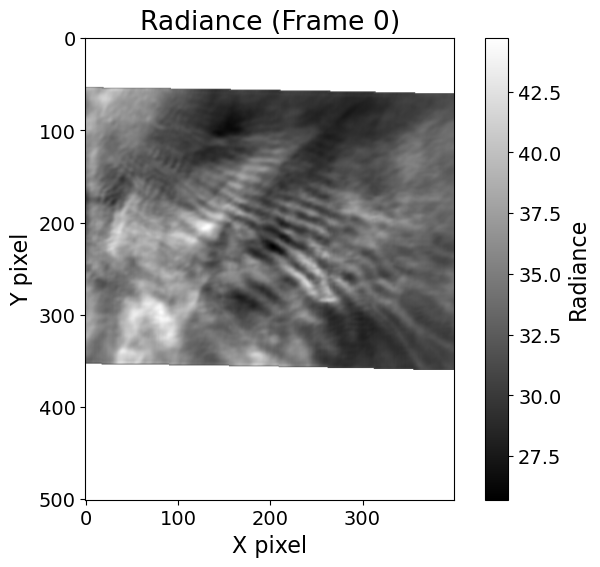

In [29]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import numpy as np

# Open the file (in the same folder as your notebook)
file_path = "awe_l5c_q20_2024165T2120_03175_v01.nc"
nc = Dataset(file_path, 'r')

# Read the radiance variable
radiance = nc.variables['Radiance'][:]
print("Radiance shape:", radiance.shape)

# Plot the first frame
plt.figure(figsize=(8, 6))
plt.imshow(radiance[0, :, 3100:3500], cmap='gray')
plt.title('Radiance (Frame 0)')

plt.colorbar(label='Radiance')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.show()

nc.close()


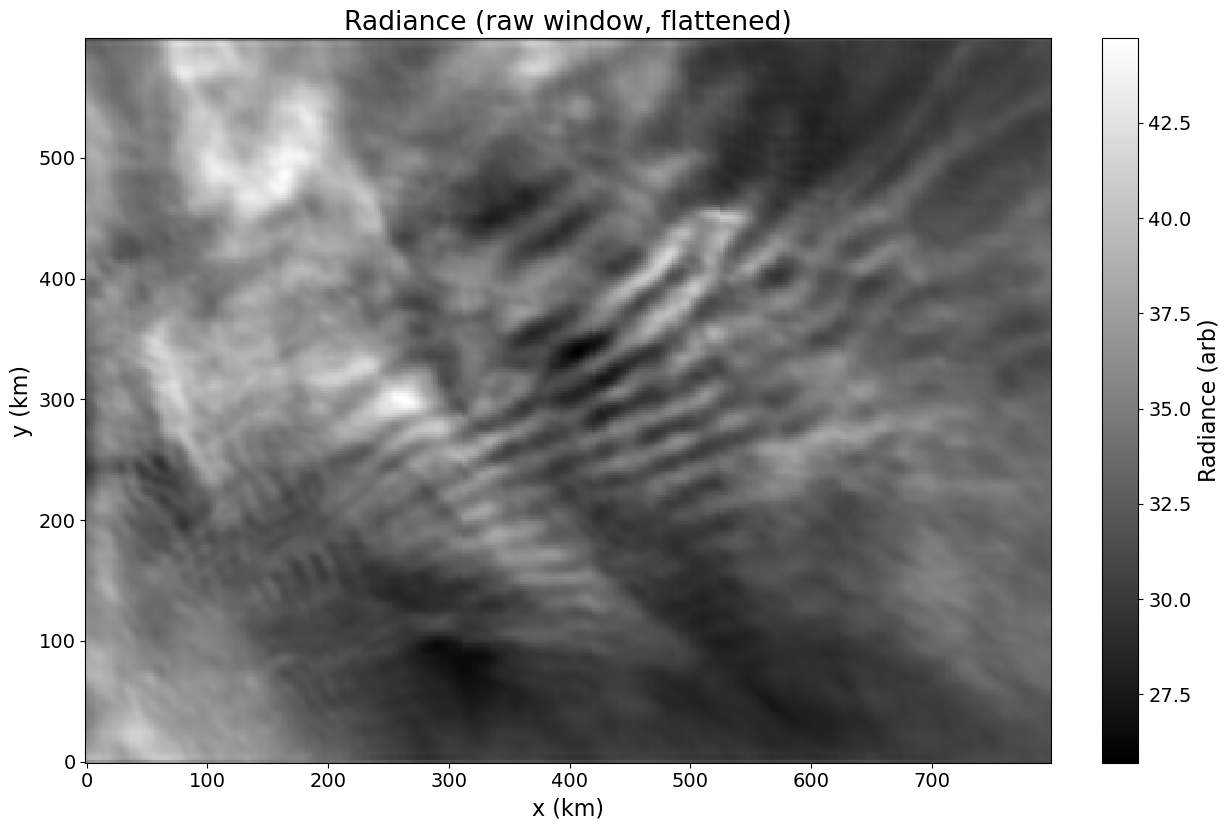

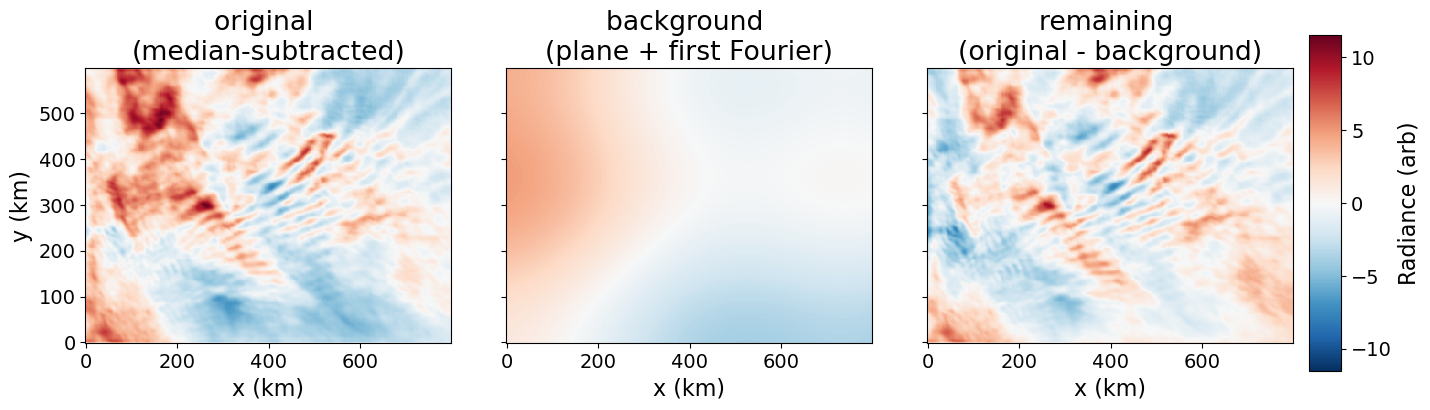

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.020518286742501 idx= (np.int64(17), np.int64(13), np.int64(234), np.int64(189))
selected elements: 129677
------------
cluster= 1
amplitude= 0.8371188786017891 idx= (np.int64(15), np.int64(11), np.int64(230), np.int64(144))
selected elements: 52840
------------
cluster= 2
amplitude= 0.5954590264365733 idx= (np.int64(17), np.int64(15), np.int64(256), np.int64(207))
selected elements: 13271
------------
cluster= 3
amplitude= 0.5408129443512173 idx= (np.int64(14), np.int64(12), np.int64(168), np.int64(133))
selected elements: 10717


C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 37.34it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


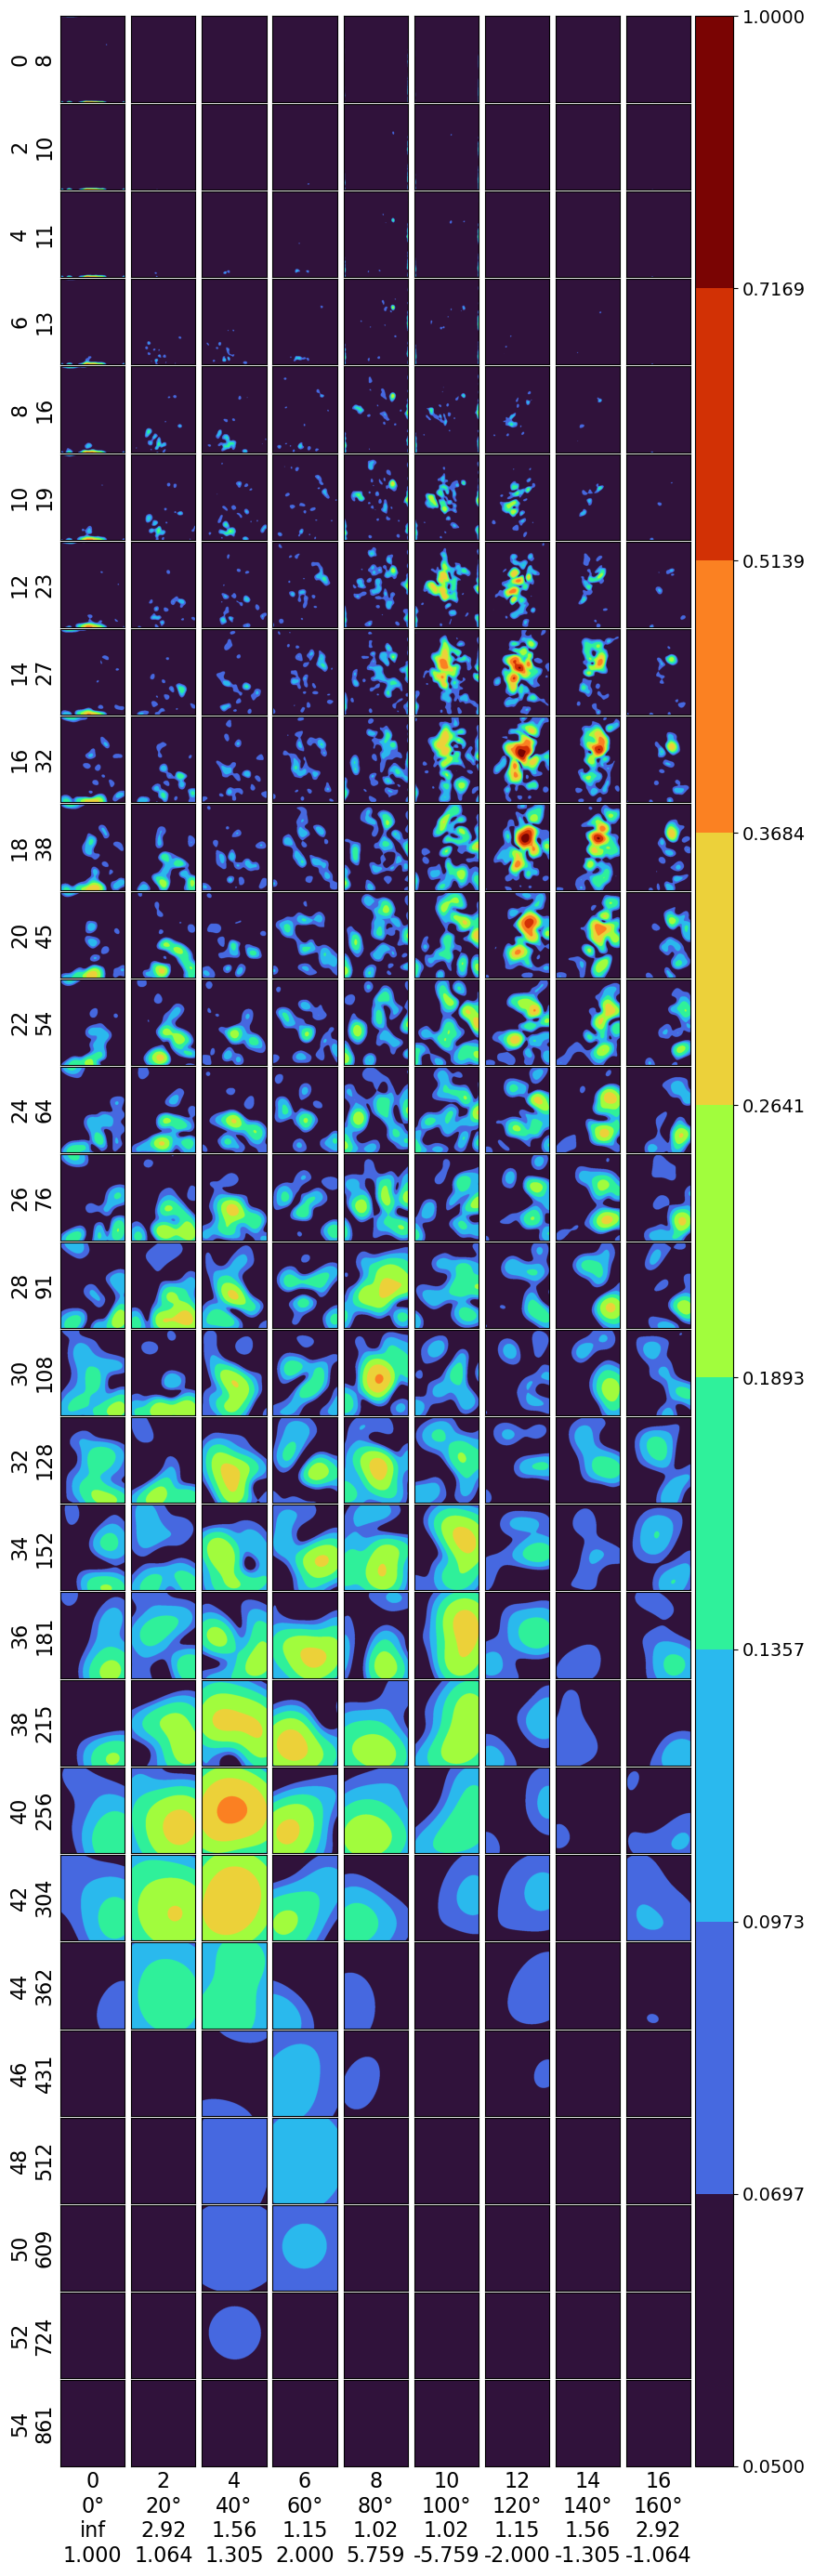

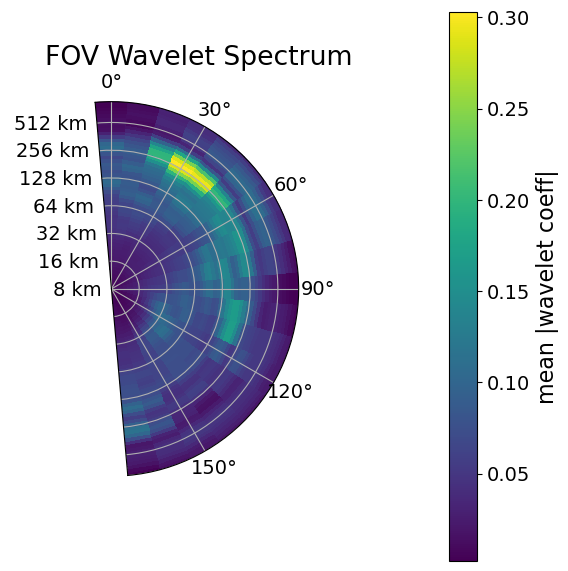

Cluster 0: amp=1.021, lamx=-54.3, lamy=45.6, lam=34.9
Cluster 1: amp=0.837, lamx=-85.8, lamy=31.2, lam=29.3
Cluster 2: amp=0.595, lamx=-40.3, lamy=69.8, lam=34.9
Cluster 3: amp=0.541, lamx=-53.8, lamy=31.1, lam=26.9


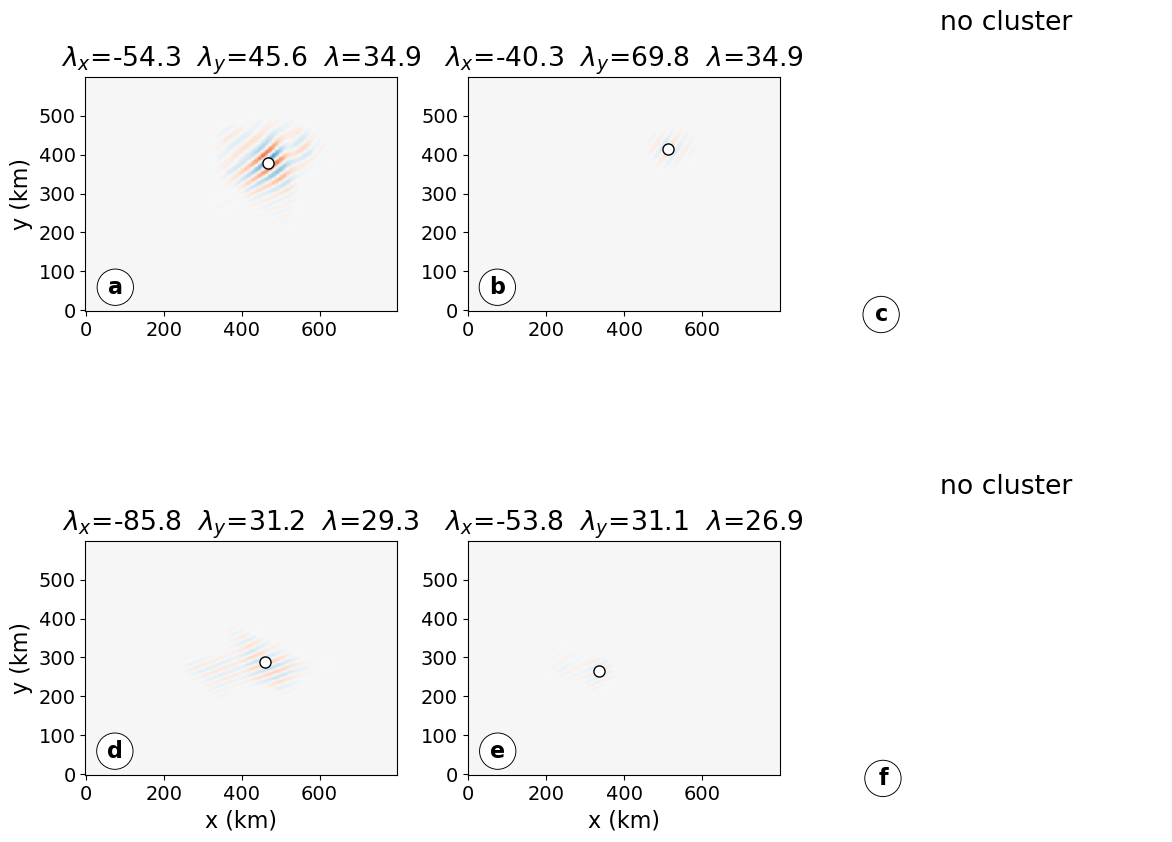

In [1]:
# example_decompose2d_from_nc.py
# Load a radiance window from an AWE NetCDF file, run juwavelet 2D CWT,
# and plot components. No files written.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Tuple
from netCDF4 import Dataset

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
FILE_PATH = "awe_l5c_q20_2024165T2120_03175_v01.nc"  # same folder as notebook/script
FRAME_IDX = 0

# Use pixels for now (unknown km/pixel). Adjust slices to taste.
X_SLICE = slice(3100, 3500)   # columns
Y_SLICE = slice(None, None)   # rows (all) after flatten/crop

# Optional preprocessing
REMOVE_TREND = True      # subtract 2D plane (least squares) before CWT
STANDARDIZE = True       # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0   # 0 disables, else pixels (e.g., 0.8)

# Wavelet params (tune if desired)
S0 = 8
DJ = 1/8
JS = 55
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel)
DX_KM = 2.0
DY_KM = 2.0

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def read_radiance_frame(path: str, frame_idx: int) -> np.ndarray:
    """
    Read one 2D radiance frame (ny, nx) from the NetCDF file.
    """
    with Dataset(path, "r") as nc:
        rad = nc.variables["Radiance"][:]  # shape (nframe, ny, nx)
    if rad.ndim != 3:
        raise ValueError(f"Radiance expected 3D (t,y,x); got {rad.shape}")
    return np.asarray(rad[frame_idx, :, :], dtype=float)  # (ny, nx)


def flatten_swath(Z: np.ndarray, target_ny: int = 300) -> np.ndarray:
    """
    Shift each column so that its lowest valid pixel (bottom) aligns
    along a straight line, then crop in y so the result has exactly
    target_ny rows if possible.

    After this, we will treat y indices as 0..target_ny-1.
    """
    ny, nx = Z.shape
    out = np.full_like(Z, np.nan)

    # Find the bottom (last finite index) of each column
    bottoms = []
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            bottoms.append(np.nan)
        else:
            bottoms.append(valid_idx.max())

    bottoms = np.array(bottoms)
    valid_bottoms = bottoms[np.isfinite(bottoms)]
    if valid_bottoms.size == 0:
        # Nothing finite, just median fill and crop
        med = np.nanmedian(Z)
        out = np.nan_to_num(Z, nan=med, posinf=med, neginf=med)
        if ny > target_ny:
            out = out[-target_ny:, :]
        return out

    # Common bottom index across all columns (straight bottom)
    max_bottom = int(valid_bottoms.max())

    # Align each column so its bottom lands at max_bottom
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            continue
        bottom = valid_idx.max()
        shift = max_bottom - bottom  # positive => move column downward
        if shift == 0:
            out[:, j] = col
        elif shift > 0:
            # shift downward: bottom -> max_bottom
            out[shift:, j] = col[:ny - shift]
        else:
            # If bottom is already below max_bottom (rare), shift up
            shift_up = -shift
            out[:ny - shift_up, j] = col[shift_up:]

    # Fill NaNs with median
    med = np.nanmedian(out)
    out = np.nan_to_num(out, nan=med, posinf=med, neginf=med)

    # Crop in y so final image has y indices 0..target_ny-1
    # We keep the bottom anchored and trim from the top if needed.
    if target_ny is not None and ny > target_ny:
        start = max_bottom + 1 - target_ny
        if start < 0:
            start = 0
        end = start + target_ny
        out = out[start:end, :]

    return out


def load_radiance_window_from_array(
    Z: np.ndarray,
    xsl: slice,
    ysl: slice,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Take a 2D array Z (already flattened and cropped), apply the
    slices in y and x, and return (x_coords, y_coords, window).

    Z shape: (ny, nx). After flatten_swath with target_ny=300,
    ny should be 300 and y will run from 0 to 299.
    """
    win = np.asarray(Z[ysl, xsl], dtype=float)
    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)
    return x, y, win


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward compatible helper: remove 2D plane from Z.
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        # If SciPy is not available, fall back to no blur
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="gray")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Radiance (arb)")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field (median-subtracted)
      (b) background = 2D plane + first Fourier component in x and y (median-subtracted)
      (c) remaining = original - background  (NO extra median subtraction)
    """
    # Median from the original
    med = np.nanmedian(original)

    # Median-center original & background only
    orig_c = original - med
    bg_c = background - med

    # Remaining should be exactly original - background (no extra shift)
    rem_c = original - background   # ignore 'remaining' argument to avoid double-shift

    # Common symmetric vmin/vmax so 0 is centered
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    im0 = axs[0].pcolormesh(
        x1d, y1d, orig_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[0].set_title("original \n(median-subtracted)")

    axs[1].pcolormesh(
        x1d, y1d, bg_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[1].set_title("background \n(plane + first Fourier)")

    axs[2].pcolormesh(
        x1d, y1d, rem_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[2].set_title("remaining \n(original - background)")

    for ax in axs:
        ax.set_xlabel("x (km)")
        ax.set_aspect("equal", adjustable="box")
    axs[0].set_ylabel("y (km)")

    # Leave room on the right for colorbar
    fig.subplots_adjust(right=0.88, wspace=0.15)

    # Colorbar axis
    cax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im0, cax=cax)
    cbar.set_label("Radiance (arb)")

    plt.show()

def plot_fov_wavelet_spectrum(cwt, stat: str = "mean"):
    """
    Make a 0–180° half-circle polar plot of wave energy vs orientation and wavelength.
    Radial axis uses the juwavelet wavelengths (km), log-scaled.
    Major tick labels: 8, 16, 32, 64, 128, ...
    """

    import matplotlib.pyplot as plt

    # -----------------------------
    # 1. Compute amplitude statistic
    # -----------------------------
    amp = np.abs(cwt["decomposition"])  # (ns, nt, nx, ny)

    if stat == "mean":
        spec = np.nanmean(amp, axis=(2, 3))  # (ns, nt)
    elif stat == "max":
        spec = np.nanmax(amp, axis=(2, 3))   # (ns, nt)
    else:
        raise ValueError("stat must be 'mean' or 'max'")

    # -----------------------------
    # 2. Get wavelengths and angles
    # -----------------------------
    # wavelength array may be (ns, nt) or (ns,)
    if "wavelength" in cwt:
        lam = np.asarray(cwt["wavelength"])
    else:
        lam = np.asarray(cwt["period"])  # fallback

    # make lam1d = (ns,)
    lam1d = lam[:, 0] if lam.ndim == 2 else lam

    # angular centers (theta): in radians, 0..π
    theta_arr = np.asarray(cwt["theta"])
    theta1d = theta_arr[0, :] if theta_arr.ndim == 2 else theta_arr

    # -----------------------------
    # 3. Build edge grids for pcolormesh
    # -----------------------------
    def edges(x):
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate([[first], mid, [last]])

    lam_edges = edges(lam1d)
    th_edges = edges(theta1d)

    TH, R = np.meshgrid(th_edges, lam_edges)

    # -----------------------------
    # 4. Plot
    # -----------------------------
    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={"projection": "polar"}
    )

    # Half circle: 0° to 180° only
    ax.set_thetamin(-5)
    ax.set_thetamax(175)

    # Put 0° at "North" and rotate clockwise (AWE convention)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Log radial scale
    ax.set_yscale("log")
    ax.set_ylim(lam1d.min(), lam1d.max())

    # Major ticks at nice wavelengths
    major_ticks = []
    for v in [8, 16, 32, 64, 128, 256, 512]:
        if lam1d.min() <= v <= lam1d.max():
            major_ticks.append(v)
    ax.set_yticks(major_ticks)
    ax.set_yticklabels([f"{int(v)} km" for v in major_ticks])

    # pcolormesh
    im = ax.pcolormesh(TH, R, spec, shading="auto", cmap="viridis")

    ax.set_title("FOV Wavelet Spectrum", pad=24)

    cbar = fig.colorbar(im, pad=0.12)
    cbar.set_label("mean |wavelet coeff|" if stat == "mean" else "max |wavelet coeff|")

    plt.tight_layout()
    plt.show()
    
# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Read full 2D radiance frame
    rad2d = read_radiance_frame(FILE_PATH, FRAME_IDX)

    # 2) Flatten swath and crop so y runs from 0 to 299 (300 rows)
    rad2d_flat = flatten_swath(rad2d, target_ny=300)

    # 3) Apply window to the flattened/cropped field (in pixels)
    x1d_pix, y1d_pix, wave = load_radiance_window_from_array(
        rad2d_flat, X_SLICE, Y_SLICE
    )

    # Convert to km for plotting
    x1d_km = x1d_pix * DX_KM
    y1d_km = y1d_pix * DY_KM

    # Quicklook of the flattened cropped window (km axes)
    quicklook(x1d_km, y1d_km, wave, "Radiance (raw window, flattened)")

    # ----------------------
    # Background separation:
    # plane + first Fourier component in x and y
    # ----------------------
    proc = wave.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc)
        detrended = proc - plane
    else:
        plane = np.zeros_like(proc)
        detrended = proc

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc - background

    # Three panel plot: original, background, remaining
    quicklook_background_decomp(x1d_km, y1d_km, proc, background, remaining)

    # Continue preprocessing on the remaining field
    proc = remaining.copy()

    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        if s > 0:
            proc = (proc - m) / s
        else:
            proc = proc - m

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); our arrays are (ny, nx) so transpose
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX_KM, dy=DY_KM, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.3)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)
    
    # New: FOV wavelet spectrum
    plot_fov_wavelet_spectrum(cwt, stat="mean")

    # --------------------------
    # Component panels: 6 largest clusters
    # --------------------------
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2) -> 6 axes

    # Use the same color scale for all six panels
    opts = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0
    axes_flat = axs.reshape(-1)

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"   # scientific
        elif abs(v) >= 100:
            return f"{v:.0f}"   # no decimals
        else:
            return f"{v:.1f}"   # one decimal

    if n_clusters == 0:
        # Fallback: nothing found
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        # Sort clusters by amplitude (largest first)
        order = np.argsort(amps)[::-1]
        n_show = min(6, n_clusters)
        biggest = order[:n_show]

        for ax, k in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != k] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            # Median-center this reconstruction for symmetric color scale
            rec_centered = rec.T - np.median(rec)

            # Wavelengths for this cluster
            udx = idxs[k]          # may be (s_idx, t_idx, i, j, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"cluster {k}  "
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d_km, y1d_km, rec_centered, **opts)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d_km[max_idx[0]],
                y1d_km[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            print(
                f"Cluster {k}: amp={amps[k]:.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )

        # If fewer than 6 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # labels (now km)
    for ax in axs[:, 1]:
        ax.set_xlabel("x (km)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (km)")

    # Keep aspect ratio for all subplots
    for ax in axs.reshape(-1):
        ax.set_aspect("equal", adjustable="box")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


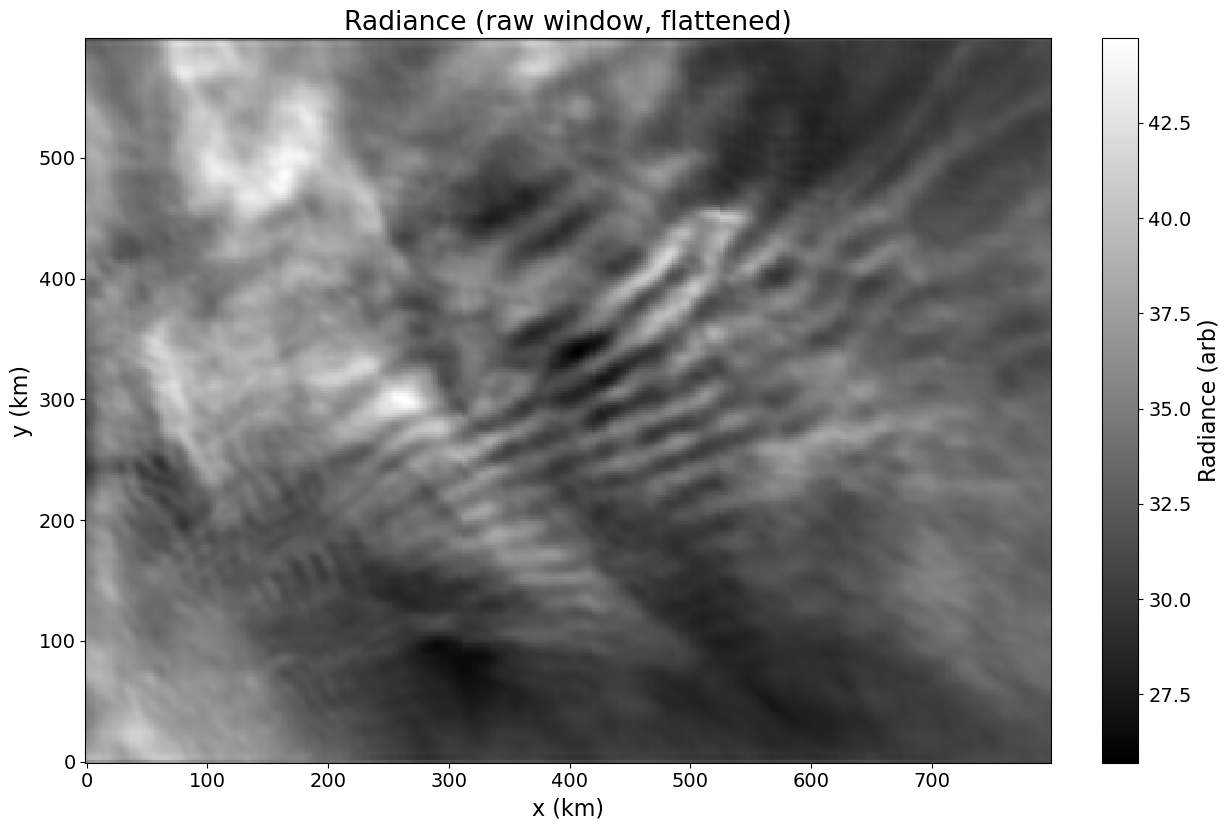

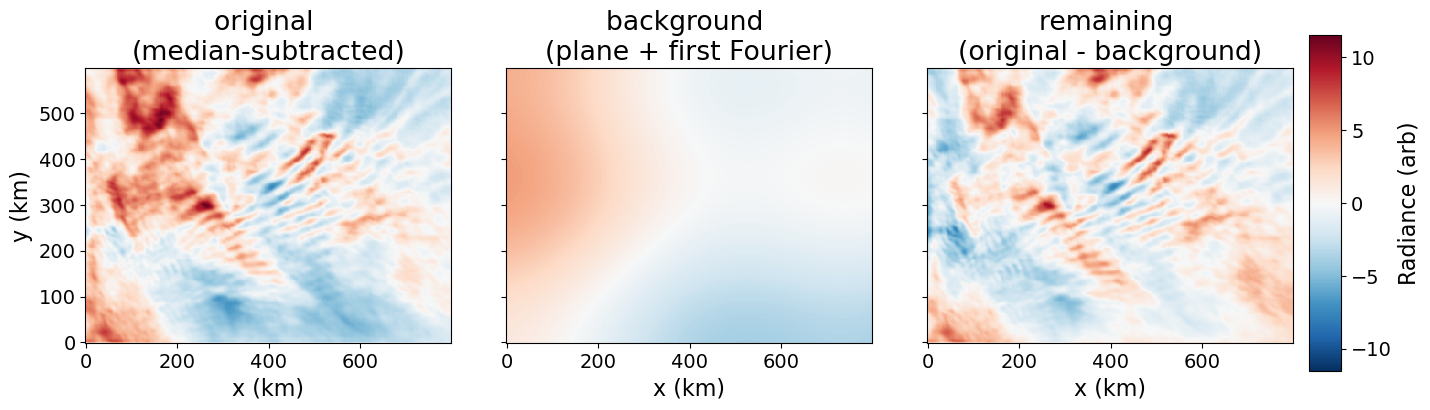

/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.0205182867425016 idx= (17, 13, 234, 189)
selected elements: 129677
------------
cluster= 1
amplitude= 0.8371188786017892 idx= (15, 11, 230, 144)
selected elements: 52840
------------
cluster= 2
amplitude= 0.5954590264365738 idx= (17, 15, 256, 207)
selected elements: 13271
------------
cluster= 3
amplitude= 0.5408129443512175 idx= (14, 12, 168, 133)
selected elements: 10717


/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████| 28/28 [00:00<00:00, 32.13it/s]
/Users/anhphan/opt/anaconda3/envs/juwavelet_env/lib/python3.10/site-packages/juwavelet/utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


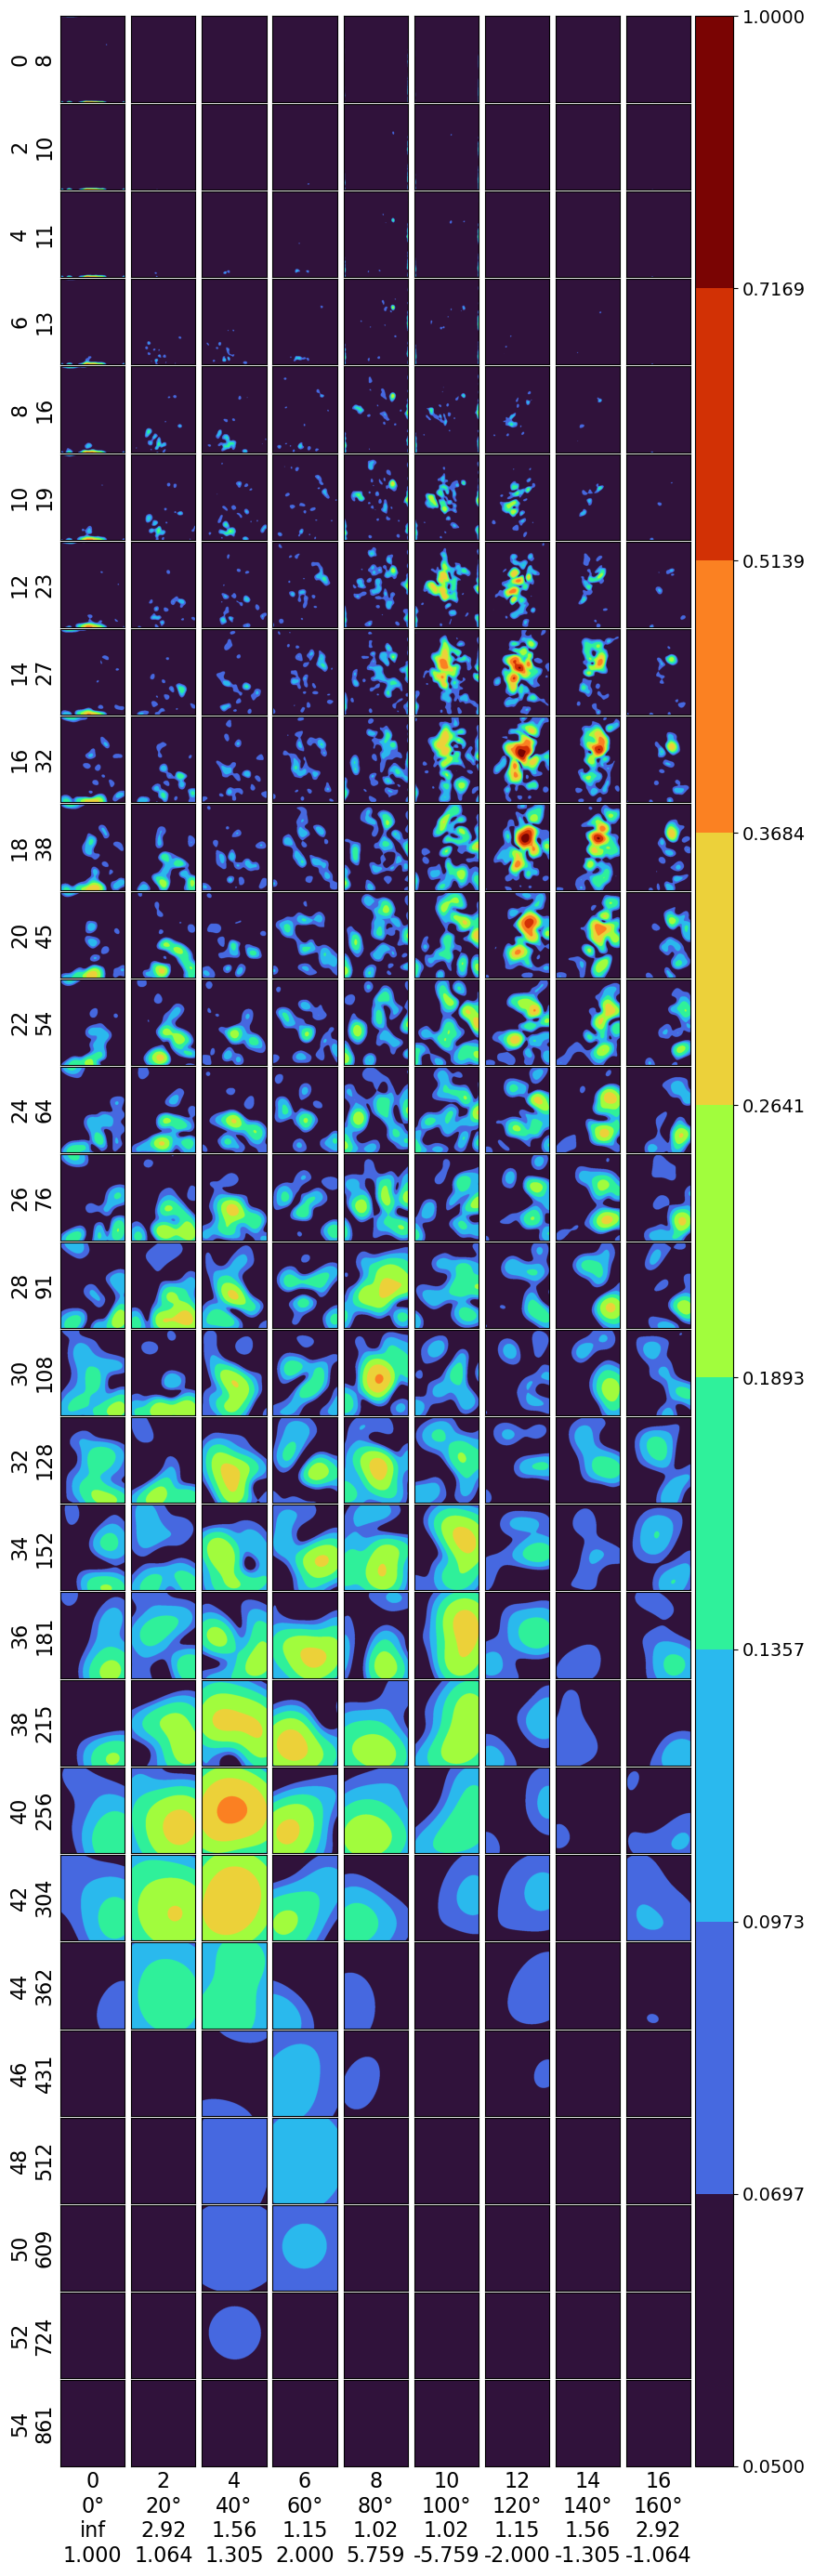

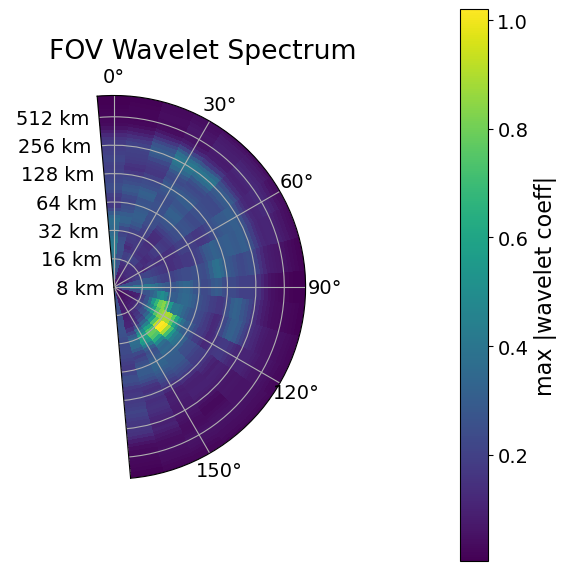

Cluster 0: amp=1.021, lamx=-54.3, lamy=45.6, lam=34.9
Cluster 1: amp=0.837, lamx=-85.8, lamy=31.2, lam=29.3
Cluster 2: amp=0.595, lamx=-40.3, lamy=69.8, lam=34.9
Cluster 3: amp=0.541, lamx=-53.8, lamy=31.1, lam=26.9


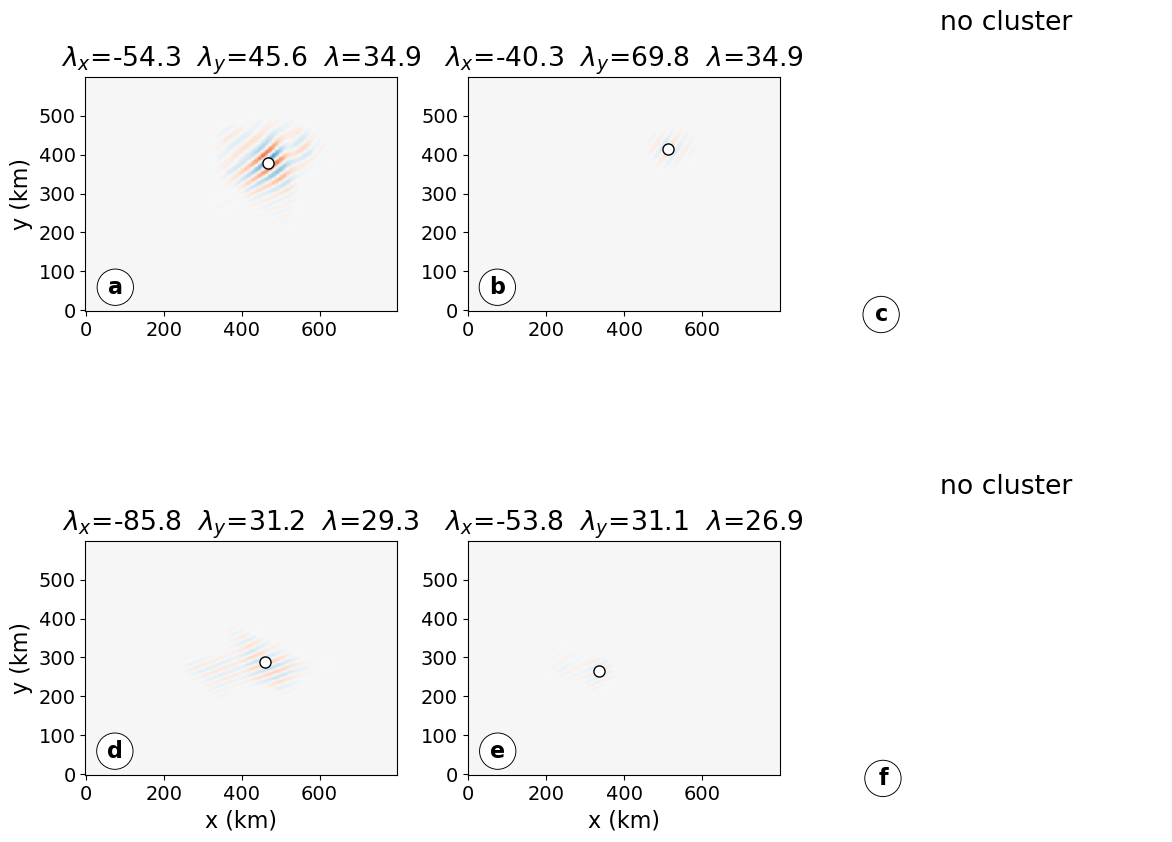

In [32]:
# example_decompose2d_from_nc.py
# Load a radiance window from an AWE NetCDF file, run juwavelet 2D CWT,
# and plot components. No files written.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Tuple
from netCDF4 import Dataset

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
FILE_PATH = "awe_l5c_q20_2024165T2120_03175_v01.nc"  # same folder as notebook/script
FRAME_IDX = 0

# Use pixels for now (unknown km/pixel). Adjust slices to taste.
X_SLICE = slice(3100, 3500)   # columns
Y_SLICE = slice(None, None)   # rows (all) after flatten/crop

# Optional preprocessing
REMOVE_TREND = True      # subtract 2D plane (least squares) before CWT
STANDARDIZE = True       # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0   # 0 disables, else pixels (e.g., 0.8)

# Wavelet params (tune if desired)
S0 = 8
DJ = 1/8
JS = 55
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel)
DX_KM = 2.0
DY_KM = 2.0

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def read_radiance_frame(path: str, frame_idx: int) -> np.ndarray:
    """
    Read one 2D radiance frame (ny, nx) from the NetCDF file.
    """
    with Dataset(path, "r") as nc:
        rad = nc.variables["Radiance"][:]  # shape (nframe, ny, nx)
    if rad.ndim != 3:
        raise ValueError(f"Radiance expected 3D (t,y,x); got {rad.shape}")
    return np.asarray(rad[frame_idx, :, :], dtype=float)  # (ny, nx)


def flatten_swath(Z: np.ndarray, target_ny: int = 300) -> np.ndarray:
    """
    Shift each column so that its lowest valid pixel (bottom) aligns
    along a straight line, then crop in y so the result has exactly
    target_ny rows if possible.

    After this, we will treat y indices as 0..target_ny-1.
    """
    ny, nx = Z.shape
    out = np.full_like(Z, np.nan)

    # Find the bottom (last finite index) of each column
    bottoms = []
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            bottoms.append(np.nan)
        else:
            bottoms.append(valid_idx.max())

    bottoms = np.array(bottoms)
    valid_bottoms = bottoms[np.isfinite(bottoms)]
    if valid_bottoms.size == 0:
        # Nothing finite, just median fill and crop
        med = np.nanmedian(Z)
        out = np.nan_to_num(Z, nan=med, posinf=med, neginf=med)
        if ny > target_ny:
            out = out[-target_ny:, :]
        return out

    # Common bottom index across all columns (straight bottom)
    max_bottom = int(valid_bottoms.max())

    # Align each column so its bottom lands at max_bottom
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            continue
        bottom = valid_idx.max()
        shift = max_bottom - bottom  # positive => move column downward
        if shift == 0:
            out[:, j] = col
        elif shift > 0:
            # shift downward: bottom -> max_bottom
            out[shift:, j] = col[:ny - shift]
        else:
            # If bottom is already below max_bottom (rare), shift up
            shift_up = -shift
            out[:ny - shift_up, j] = col[shift_up:]

    # Fill NaNs with median
    med = np.nanmedian(out)
    out = np.nan_to_num(out, nan=med, posinf=med, neginf=med)

    # Crop in y so final image has y indices 0..target_ny-1
    # We keep the bottom anchored and trim from the top if needed.
    if target_ny is not None and ny > target_ny:
        start = max_bottom + 1 - target_ny
        if start < 0:
            start = 0
        end = start + target_ny
        out = out[start:end, :]

    return out


def load_radiance_window_from_array(
    Z: np.ndarray,
    xsl: slice,
    ysl: slice,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Take a 2D array Z (already flattened and cropped), apply the
    slices in y and x, and return (x_coords, y_coords, window).

    Z shape: (ny, nx). After flatten_swath with target_ny=300,
    ny should be 300 and y will run from 0 to 299.
    """
    win = np.asarray(Z[ysl, xsl], dtype=float)
    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)
    return x, y, win


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward compatible helper: remove 2D plane from Z.
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        # If SciPy is not available, fall back to no blur
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="gray")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Radiance (arb)")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field (median-subtracted)
      (b) background = 2D plane + first Fourier component in x and y (median-subtracted)
      (c) remaining = original - background  (NO extra median subtraction)
    """
    # Median from the original
    med = np.nanmedian(original)

    # Median-center original & background only
    orig_c = original - med
    bg_c = background - med

    # Remaining should be exactly original - background (no extra shift)
    rem_c = original - background   # ignore 'remaining' argument to avoid double-shift

    # Common symmetric vmin/vmax so 0 is centered
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    im0 = axs[0].pcolormesh(
        x1d, y1d, orig_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[0].set_title("original \n(median-subtracted)")

    axs[1].pcolormesh(
        x1d, y1d, bg_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[1].set_title("background \n(plane + first Fourier)")

    axs[2].pcolormesh(
        x1d, y1d, rem_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[2].set_title("remaining \n(original - background)")

    for ax in axs:
        ax.set_xlabel("x (km)")
        ax.set_aspect("equal", adjustable="box")
    axs[0].set_ylabel("y (km)")

    # Leave room on the right for colorbar
    fig.subplots_adjust(right=0.88, wspace=0.15)

    # Colorbar axis
    cax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im0, cax=cax)
    cbar.set_label("Radiance (arb)")

    plt.show()

def plot_fov_wavelet_spectrum(cwt, stat: str = "mean"):
    """
    Make a 0–180° half-circle polar plot of wave energy vs orientation and wavelength.
    Radial axis uses the juwavelet wavelengths (km), log-scaled.
    Major tick labels: 8, 16, 32, 64, 128, ...
    """

    import matplotlib.pyplot as plt

    # -----------------------------
    # 1. Compute amplitude statistic
    # -----------------------------
    amp = np.abs(cwt["decomposition"])  # (ns, nt, nx, ny)

    if stat == "mean":
        spec = np.nanmean(amp, axis=(2, 3))  # (ns, nt)
    elif stat == "max":
        spec = np.nanmax(amp, axis=(2, 3))   # (ns, nt)
    else:
        raise ValueError("stat must be 'mean' or 'max'")

    # -----------------------------
    # 2. Get wavelengths and angles
    # -----------------------------
    # wavelength array may be (ns, nt) or (ns,)
    if "wavelength" in cwt:
        lam = np.asarray(cwt["wavelength"])
    else:
        lam = np.asarray(cwt["period"])  # fallback

    # make lam1d = (ns,)
    lam1d = lam[:, 0] if lam.ndim == 2 else lam

    # angular centers (theta): in radians, 0..π
    theta_arr = np.asarray(cwt["theta"])
    theta1d = theta_arr[0, :] if theta_arr.ndim == 2 else theta_arr

    # -----------------------------
    # 3. Build edge grids for pcolormesh
    # -----------------------------
    def edges(x):
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate([[first], mid, [last]])

    lam_edges = edges(lam1d)
    th_edges = edges(theta1d)

    TH, R = np.meshgrid(th_edges, lam_edges)

    # -----------------------------
    # 4. Plot
    # -----------------------------
    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={"projection": "polar"}
    )

    # Half circle: 0° to 180° only
    ax.set_thetamin(-5)
    ax.set_thetamax(175)

    # Put 0° at "North" and rotate clockwise (AWE convention)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Log radial scale
    ax.set_yscale("log")
    ax.set_ylim(lam1d.min(), lam1d.max())

    # Major ticks at nice wavelengths
    major_ticks = []
    for v in [8, 16, 32, 64, 128, 256, 512]:
        if lam1d.min() <= v <= lam1d.max():
            major_ticks.append(v)
    ax.set_yticks(major_ticks)
    ax.set_yticklabels([f"{int(v)} km" for v in major_ticks])

    # pcolormesh
    im = ax.pcolormesh(TH, R, spec, shading="auto", cmap="viridis")

    ax.set_title("FOV Wavelet Spectrum", pad=24)

    cbar = fig.colorbar(im, pad=0.12)
    cbar.set_label("mean |wavelet coeff|" if stat == "mean" else "max |wavelet coeff|")

    plt.tight_layout()
    plt.show()
    
# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Read full 2D radiance frame
    rad2d = read_radiance_frame(FILE_PATH, FRAME_IDX)

    # 2) Flatten swath and crop so y runs from 0 to 299 (300 rows)
    rad2d_flat = flatten_swath(rad2d, target_ny=300)

    # 3) Apply window to the flattened/cropped field (in pixels)
    x1d_pix, y1d_pix, wave = load_radiance_window_from_array(
        rad2d_flat, X_SLICE, Y_SLICE
    )

    # Convert to km for plotting
    x1d_km = x1d_pix * DX_KM
    y1d_km = y1d_pix * DY_KM

    # Quicklook of the flattened cropped window (km axes)
    quicklook(x1d_km, y1d_km, wave, "Radiance (raw window, flattened)")

    # ----------------------
    # Background separation:
    # plane + first Fourier component in x and y
    # ----------------------
    proc = wave.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc)
        detrended = proc - plane
    else:
        plane = np.zeros_like(proc)
        detrended = proc

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc - background

    # Three panel plot: original, background, remaining
    quicklook_background_decomp(x1d_km, y1d_km, proc, background, remaining)

    # Continue preprocessing on the remaining field
    proc = remaining.copy()

    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        if s > 0:
            proc = (proc - m) / s
        else:
            proc = proc - m

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); our arrays are (ny, nx) so transpose
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX_KM, dy=DY_KM, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.3)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)
    
    # New: FOV wavelet spectrum
    plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Component panels: 6 largest clusters
    # --------------------------
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2) -> 6 axes

    # Use the same color scale for all six panels
    opts = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0
    axes_flat = axs.reshape(-1)

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"   # scientific
        elif abs(v) >= 100:
            return f"{v:.0f}"   # no decimals
        else:
            return f"{v:.1f}"   # one decimal

    if n_clusters == 0:
        # Fallback: nothing found
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        # Sort clusters by amplitude (largest first)
        order = np.argsort(amps)[::-1]
        n_show = min(6, n_clusters)
        biggest = order[:n_show]

        for ax, k in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != k] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            # Median-center this reconstruction for symmetric color scale
            rec_centered = rec.T - np.median(rec)

            # Wavelengths for this cluster
            udx = idxs[k]          # may be (s_idx, t_idx, i, j, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"cluster {k}  "
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d_km, y1d_km, rec_centered, **opts)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d_km[max_idx[0]],
                y1d_km[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            print(
                f"Cluster {k}: amp={amps[k]:.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )

        # If fewer than 6 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # labels (now km)
    for ax in axs[:, 1]:
        ax.set_xlabel("x (km)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (km)")

    # Keep aspect ratio for all subplots
    for ax in axs.reshape(-1):
        ax.set_aspect("equal", adjustable="box")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


### Decrease the threshold

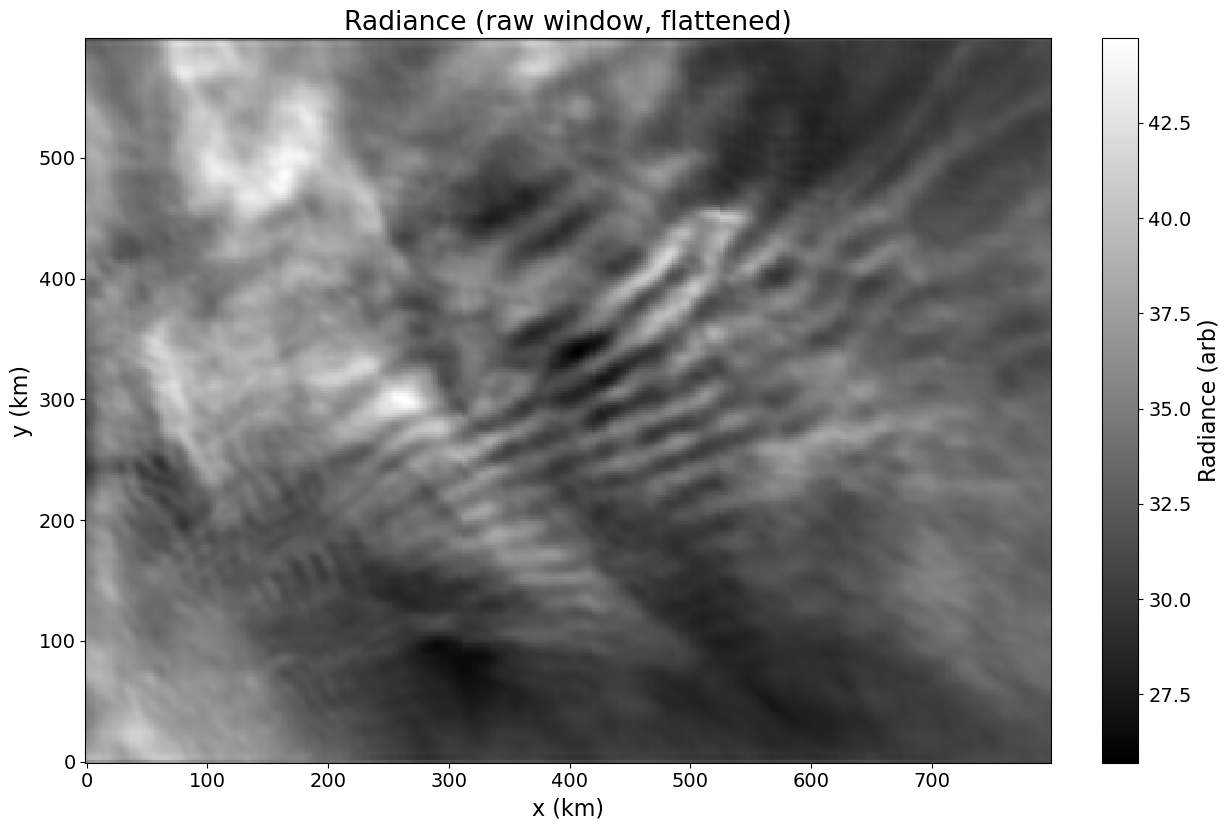

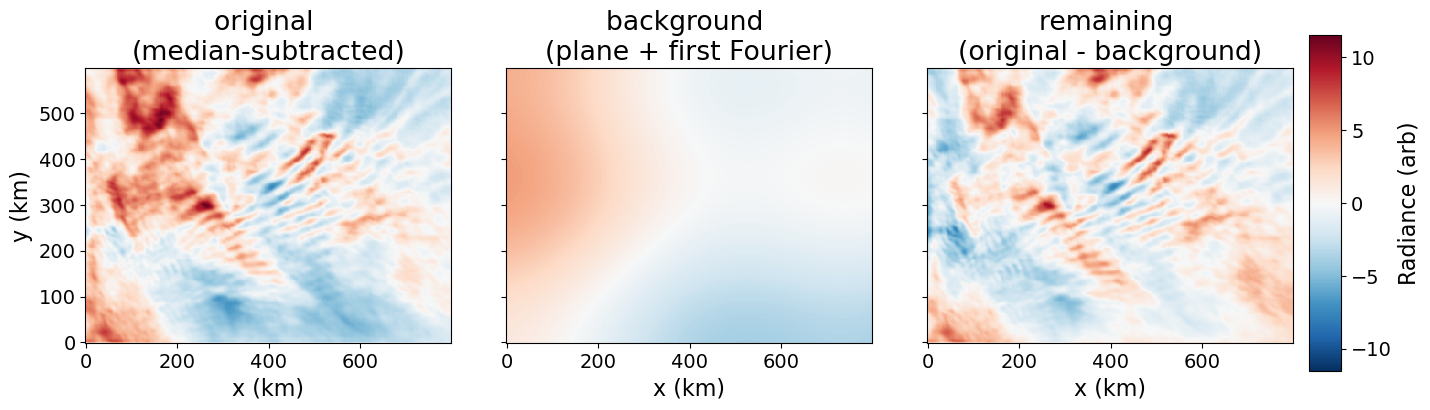

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.020518286742501 idx= (np.int64(17), np.int64(13), np.int64(234), np.int64(189))
selected elements: 1532939
------------
cluster= 1
amplitude= 0.5020586816255143 idx= (np.int64(14), np.int64(10), np.int64(238), np.int64(135))
selected elements: 51963
------------
cluster= 2
amplitude= 0.4654955265034744 idx= (np.int64(12), np.int64(12), np.int64(167), np.int64(129))
selected elements: 41481
------------
cluster= 3
amplitude= 0.43605869612796555 idx= (np.int64(0), np.int64(0), np.int64(0), np.int64(122))
selected elements: 7641
------------
cluster= 4
amplitude= 0.41730383129117077 idx= (np.int64(9), np.int64(9), np.int64(185), np.int64(298))
selected elements: 51366
------------
cluster= 5
amplitude= 0.41690744130087526 idx= (np.int64(12), np.int64(0), np.int64(1), np.int64(130))
selected elements: 338207
------------
cluster= 6
amplitude= 0.41414027458208164 idx= (np.int64(40), np.int64(3), np.int64(167), np.int64(176))
selected elements: 6366327
--

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 26.17it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


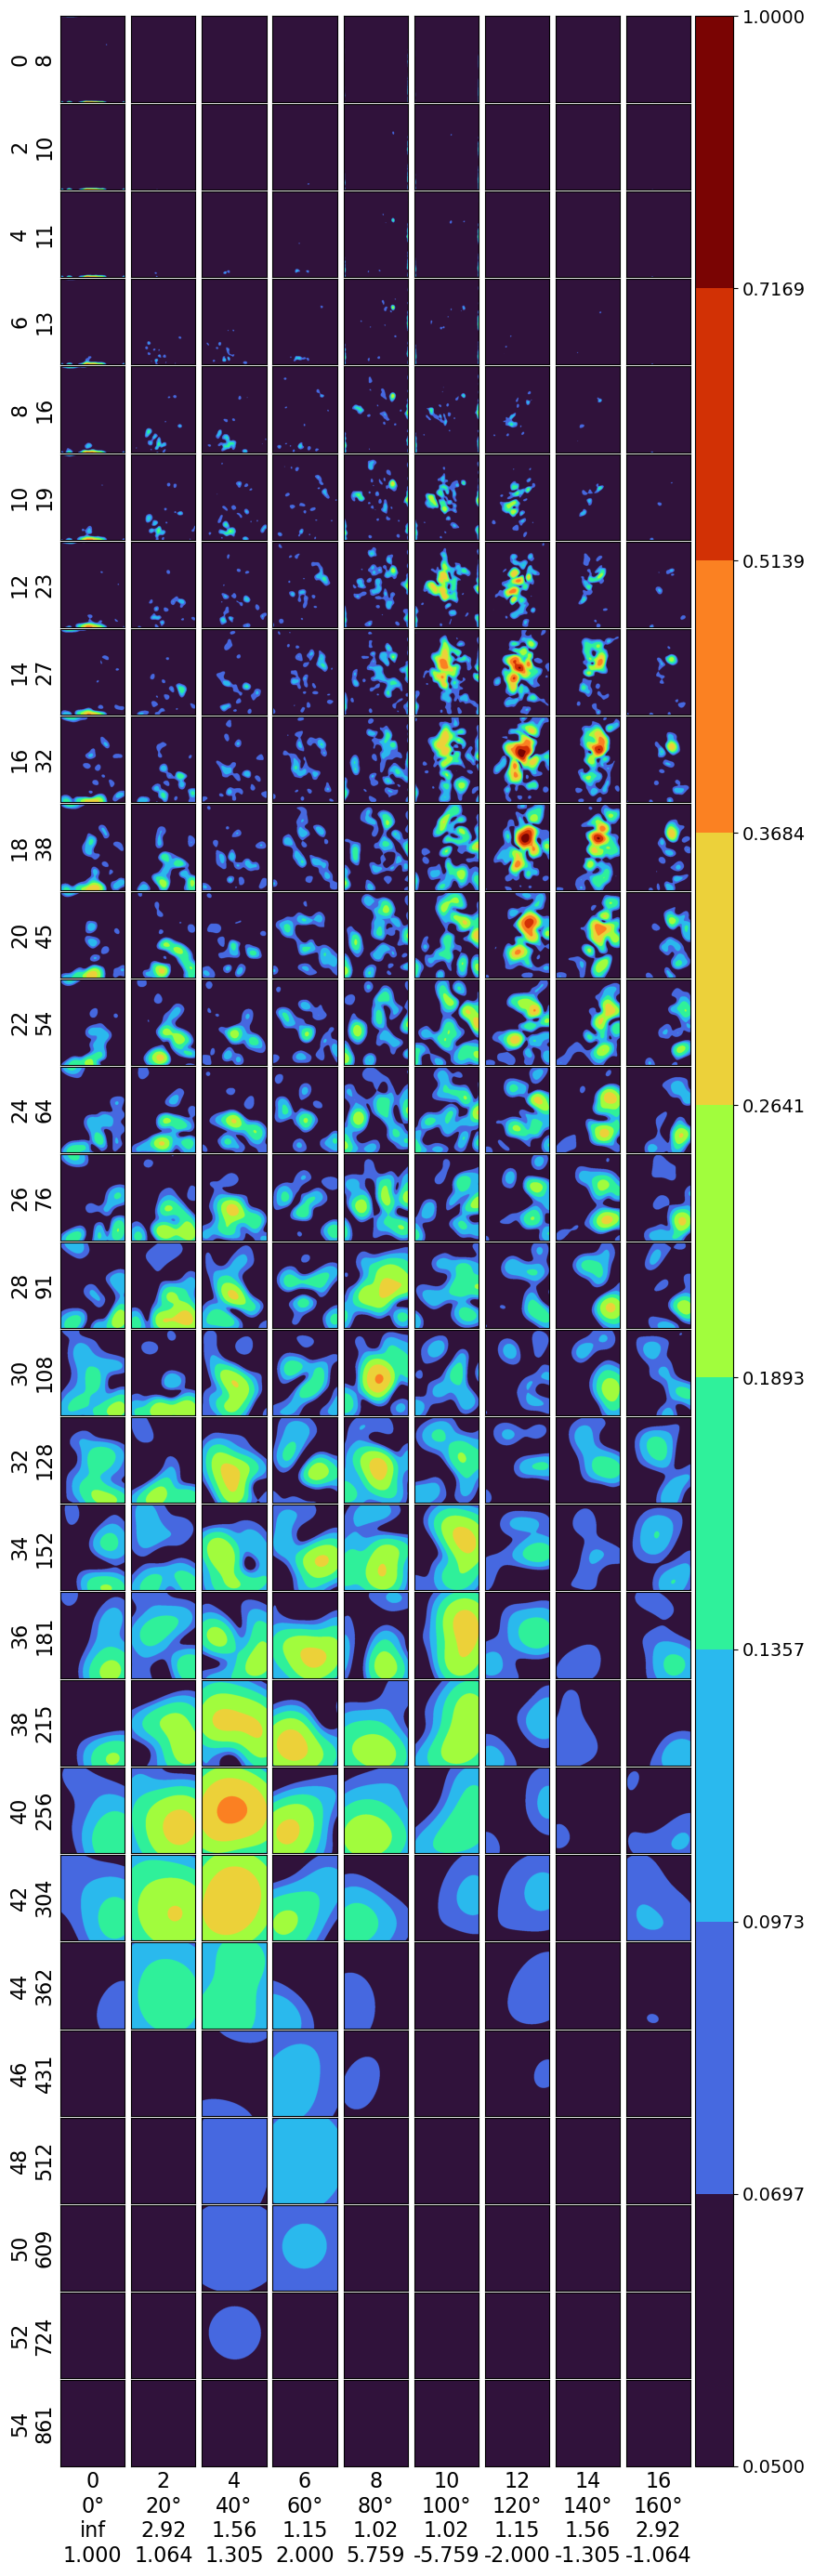

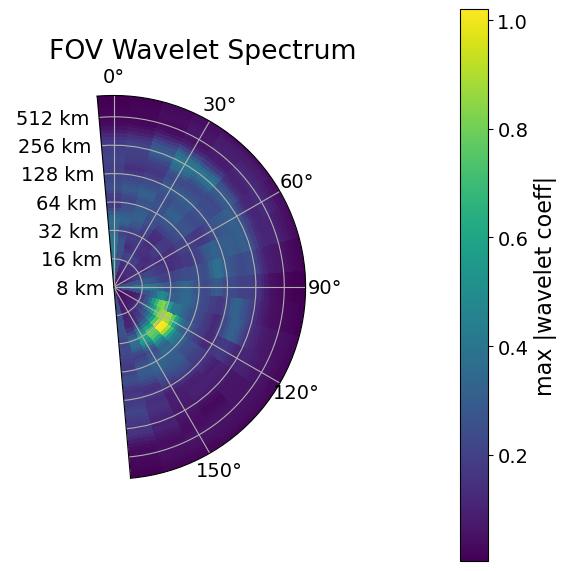

Cluster 0: amp=1.021, lamx=-54.3, lamy=45.6, lam=34.9
Cluster 1: amp=0.502, lamx=-155.0, lamy=27.3, lam=26.9
Cluster 2: amp=0.465, lamx=-45.3, lamy=26.1, lam=22.6
Cluster 3: amp=0.436, lamx=8.0, lamy=inf, lam=8.0
Cluster 4: amp=0.417, lamx=284949484778667392.0, lamy=17.4, lam=17.4
Cluster 5: amp=0.417, lamx=22.6, lamy=inf, lam=22.6


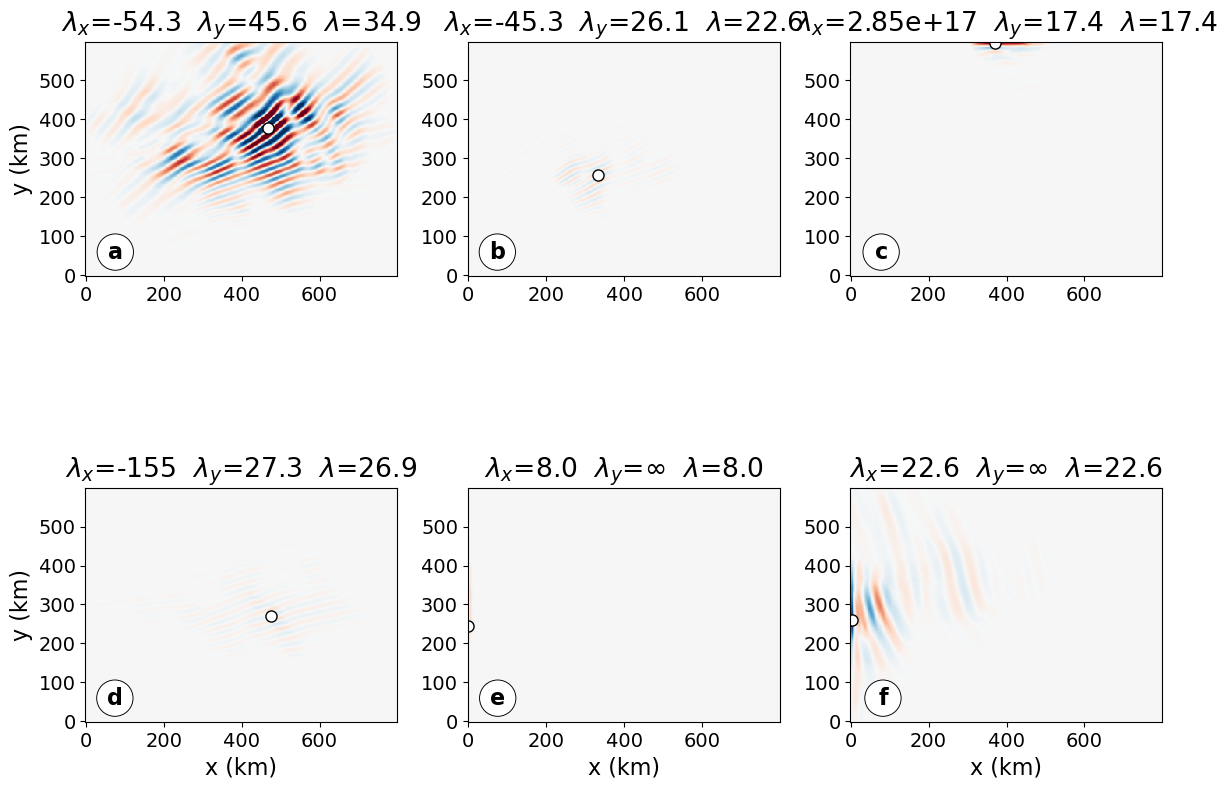

In [5]:
# example_decompose2d_from_nc.py
# Load a radiance window from an AWE NetCDF file, run juwavelet 2D CWT,
# and plot components. No files written.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Tuple
from netCDF4 import Dataset

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
FILE_PATH = "awe_l5c_q20_2024165T2120_03175_v01.nc"  # same folder as notebook/script
FRAME_IDX = 0

# Use pixels for now (unknown km/pixel). Adjust slices to taste.
X_SLICE = slice(3100, 3500)   # columns
Y_SLICE = slice(None, None)   # rows (all) after flatten/crop

# Optional preprocessing
REMOVE_TREND = True      # subtract 2D plane (least squares) before CWT
STANDARDIZE = True       # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0   # 0 disables, else pixels (e.g., 0.8)

# Wavelet params (tune if desired)
S0 = 8
DJ = 1/8
JS = 55
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel)
DX_KM = 2.0
DY_KM = 2.0

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def read_radiance_frame(path: str, frame_idx: int) -> np.ndarray:
    """
    Read one 2D radiance frame (ny, nx) from the NetCDF file.
    """
    with Dataset(path, "r") as nc:
        rad = nc.variables["Radiance"][:]  # shape (nframe, ny, nx)
    if rad.ndim != 3:
        raise ValueError(f"Radiance expected 3D (t,y,x); got {rad.shape}")
    return np.asarray(rad[frame_idx, :, :], dtype=float)  # (ny, nx)


def flatten_swath(Z: np.ndarray, target_ny: int = 300) -> np.ndarray:
    """
    Shift each column so that its lowest valid pixel (bottom) aligns
    along a straight line, then crop in y so the result has exactly
    target_ny rows if possible.

    After this, we will treat y indices as 0..target_ny-1.
    """
    ny, nx = Z.shape
    out = np.full_like(Z, np.nan)

    # Find the bottom (last finite index) of each column
    bottoms = []
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            bottoms.append(np.nan)
        else:
            bottoms.append(valid_idx.max())

    bottoms = np.array(bottoms)
    valid_bottoms = bottoms[np.isfinite(bottoms)]
    if valid_bottoms.size == 0:
        # Nothing finite, just median fill and crop
        med = np.nanmedian(Z)
        out = np.nan_to_num(Z, nan=med, posinf=med, neginf=med)
        if ny > target_ny:
            out = out[-target_ny:, :]
        return out

    # Common bottom index across all columns (straight bottom)
    max_bottom = int(valid_bottoms.max())

    # Align each column so its bottom lands at max_bottom
    for j in range(nx):
        col = Z[:, j]
        valid_idx = np.where(np.isfinite(col))[0]
        if len(valid_idx) == 0:
            continue
        bottom = valid_idx.max()
        shift = max_bottom - bottom  # positive => move column downward
        if shift == 0:
            out[:, j] = col
        elif shift > 0:
            # shift downward: bottom -> max_bottom
            out[shift:, j] = col[:ny - shift]
        else:
            # If bottom is already below max_bottom (rare), shift up
            shift_up = -shift
            out[:ny - shift_up, j] = col[shift_up:]

    # Fill NaNs with median
    med = np.nanmedian(out)
    out = np.nan_to_num(out, nan=med, posinf=med, neginf=med)

    # Crop in y so final image has y indices 0..target_ny-1
    # We keep the bottom anchored and trim from the top if needed.
    if target_ny is not None and ny > target_ny:
        start = max_bottom + 1 - target_ny
        if start < 0:
            start = 0
        end = start + target_ny
        out = out[start:end, :]

    return out


def load_radiance_window_from_array(
    Z: np.ndarray,
    xsl: slice,
    ysl: slice,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Take a 2D array Z (already flattened and cropped), apply the
    slices in y and x, and return (x_coords, y_coords, window).

    Z shape: (ny, nx). After flatten_swath with target_ny=300,
    ny should be 300 and y will run from 0 to 299.
    """
    win = np.asarray(Z[ysl, xsl], dtype=float)
    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)
    return x, y, win


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward compatible helper: remove 2D plane from Z.
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        # If SciPy is not available, fall back to no blur
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="gray")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Radiance (arb)")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field (median-subtracted)
      (b) background = 2D plane + first Fourier component in x and y (median-subtracted)
      (c) remaining = original - background  (NO extra median subtraction)
    """
    # Median from the original
    med = np.nanmedian(original)

    # Median-center original & background only
    orig_c = original - med
    bg_c = background - med

    # Remaining should be exactly original - background (no extra shift)
    rem_c = original - background   # ignore 'remaining' argument to avoid double-shift

    # Common symmetric vmin/vmax so 0 is centered
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    im0 = axs[0].pcolormesh(
        x1d, y1d, orig_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[0].set_title("original \n(median-subtracted)")

    axs[1].pcolormesh(
        x1d, y1d, bg_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[1].set_title("background \n(plane + first Fourier)")

    axs[2].pcolormesh(
        x1d, y1d, rem_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[2].set_title("remaining \n(original - background)")

    for ax in axs:
        ax.set_xlabel("x (km)")
        ax.set_aspect("equal", adjustable="box")
    axs[0].set_ylabel("y (km)")

    # Leave room on the right for colorbar
    fig.subplots_adjust(right=0.88, wspace=0.15)

    # Colorbar axis
    cax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im0, cax=cax)
    cbar.set_label("Radiance (arb)")

    plt.show()

def plot_fov_wavelet_spectrum(cwt, stat: str = "mean"):
    """
    Make a 0–180° half-circle polar plot of wave energy vs orientation and wavelength.
    Radial axis uses the juwavelet wavelengths (km), log-scaled.
    Major tick labels: 8, 16, 32, 64, 128, ...
    """

    import matplotlib.pyplot as plt

    # -----------------------------
    # 1. Compute amplitude statistic
    # -----------------------------
    amp = np.abs(cwt["decomposition"])  # (ns, nt, nx, ny)

    if stat == "mean":
        spec = np.nanmean(amp, axis=(2, 3))  # (ns, nt)
    elif stat == "max":
        spec = np.nanmax(amp, axis=(2, 3))   # (ns, nt)
    else:
        raise ValueError("stat must be 'mean' or 'max'")

    # -----------------------------
    # 2. Get wavelengths and angles
    # -----------------------------
    # wavelength array may be (ns, nt) or (ns,)
    if "wavelength" in cwt:
        lam = np.asarray(cwt["wavelength"])
    else:
        lam = np.asarray(cwt["period"])  # fallback

    # make lam1d = (ns,)
    lam1d = lam[:, 0] if lam.ndim == 2 else lam

    # angular centers (theta): in radians, 0..π
    theta_arr = np.asarray(cwt["theta"])
    theta1d = theta_arr[0, :] if theta_arr.ndim == 2 else theta_arr

    # -----------------------------
    # 3. Build edge grids for pcolormesh
    # -----------------------------
    def edges(x):
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate([[first], mid, [last]])

    lam_edges = edges(lam1d)
    th_edges = edges(theta1d)

    TH, R = np.meshgrid(th_edges, lam_edges)

    # -----------------------------
    # 4. Plot
    # -----------------------------
    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={"projection": "polar"}
    )

    # Half circle: 0° to 180° only
    ax.set_thetamin(-5)
    ax.set_thetamax(175)

    # Put 0° at "North" and rotate clockwise (AWE convention)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Log radial scale
    ax.set_yscale("log")
    ax.set_ylim(lam1d.min(), lam1d.max())

    # Major ticks at nice wavelengths
    major_ticks = []
    for v in [8, 16, 32, 64, 128, 256, 512]:
        if lam1d.min() <= v <= lam1d.max():
            major_ticks.append(v)
    ax.set_yticks(major_ticks)
    ax.set_yticklabels([f"{int(v)} km" for v in major_ticks])

    # pcolormesh
    im = ax.pcolormesh(TH, R, spec, shading="auto", cmap="viridis")

    ax.set_title("FOV Wavelet Spectrum", pad=24)

    cbar = fig.colorbar(im, pad=0.12)
    cbar.set_label("mean |wavelet coeff|" if stat == "mean" else "max |wavelet coeff|")

    plt.tight_layout()
    plt.show()
    
# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Read full 2D radiance frame
    rad2d = read_radiance_frame(FILE_PATH, FRAME_IDX)

    # 2) Flatten swath and crop so y runs from 0 to 299 (300 rows)
    rad2d_flat = flatten_swath(rad2d, target_ny=300)

    # 3) Apply window to the flattened/cropped field (in pixels)
    x1d_pix, y1d_pix, wave = load_radiance_window_from_array(
        rad2d_flat, X_SLICE, Y_SLICE
    )

    # Convert to km for plotting
    x1d_km = x1d_pix * DX_KM
    y1d_km = y1d_pix * DY_KM

    # Quicklook of the flattened cropped window (km axes)
    quicklook(x1d_km, y1d_km, wave, "Radiance (raw window, flattened)")

    # ----------------------
    # Background separation:
    # plane + first Fourier component in x and y
    # ----------------------
    proc = wave.copy()

    if REMOVE_TREND:
        plane = fit_plane(proc)
        detrended = proc - plane
    else:
        plane = np.zeros_like(proc)
        detrended = proc

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc - background

    # Three panel plot: original, background, remaining
    quicklook_background_decomp(x1d_km, y1d_km, proc, background, remaining)

    # Continue preprocessing on the remaining field
    proc = remaining.copy()

    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        if s > 0:
            proc = (proc - m) / s
        else:
            proc = proc - m

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); our arrays are (ny, nx) so transpose
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX_KM, dy=DY_KM, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.3, thr=0.1)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)
    
    # New: FOV wavelet spectrum
    plot_fov_wavelet_spectrum(cwt, stat="max")

    # --------------------------
    # Component panels: 6 largest clusters
    # --------------------------
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2) -> 6 axes

    # Use the same color scale for all six panels
    opts = {"cmap": "RdBu_r", "vmin": -1, "vmax": 1, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0
    axes_flat = axs.reshape(-1)

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"   # scientific
        elif abs(v) >= 100:
            return f"{v:.0f}"   # no decimals
        else:
            return f"{v:.1f}"   # one decimal

    if n_clusters == 0:
        # Fallback: nothing found
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        # Sort clusters by amplitude (largest first)
        order = np.argsort(amps)[::-1]
        n_show = min(6, n_clusters)
        biggest = order[:n_show]

        for ax, k in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != k] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            # Median-center this reconstruction for symmetric color scale
            rec_centered = rec.T - np.median(rec)

            # Wavelengths for this cluster
            udx = idxs[k]          # may be (s_idx, t_idx, i, j, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"cluster {k}  "
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d_km, y1d_km, rec_centered, **opts)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d_km[max_idx[0]],
                y1d_km[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            print(
                f"Cluster {k}: amp={amps[k]:.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )

        # If fewer than 6 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # labels (now km)
    for ax in axs[:, 1]:
        ax.set_xlabel("x (km)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (km)")

    # Keep aspect ratio for all subplots
    for ax in axs.reshape(-1):
        ax.set_aspect("equal", adjustable="box")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()
